In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)


In [2]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600

In [3]:
def save_plot(filename):
    plt.savefig(f"{filename}.eps", format='eps', dpi=600, bbox_inches='tight')
    print(f"saved {filename}.eps")


In [4]:
# loading CIFAR-10 directly from keras datasets
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("shape of training images:", X_train_full.shape)
print("shape of training labels:", y_train_full.shape)
print("shape of testing images :", X_test.shape)
print("shape of testing labels :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2349s 14us/step


c:\Users\Kishore\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


shape of training images: (50000, 32, 32, 3)
shape of training labels: (50000, 1)
shape of testing images : (10000, 32, 32, 3)
shape of testing labels : (10000, 1)


saved sample_images.eps


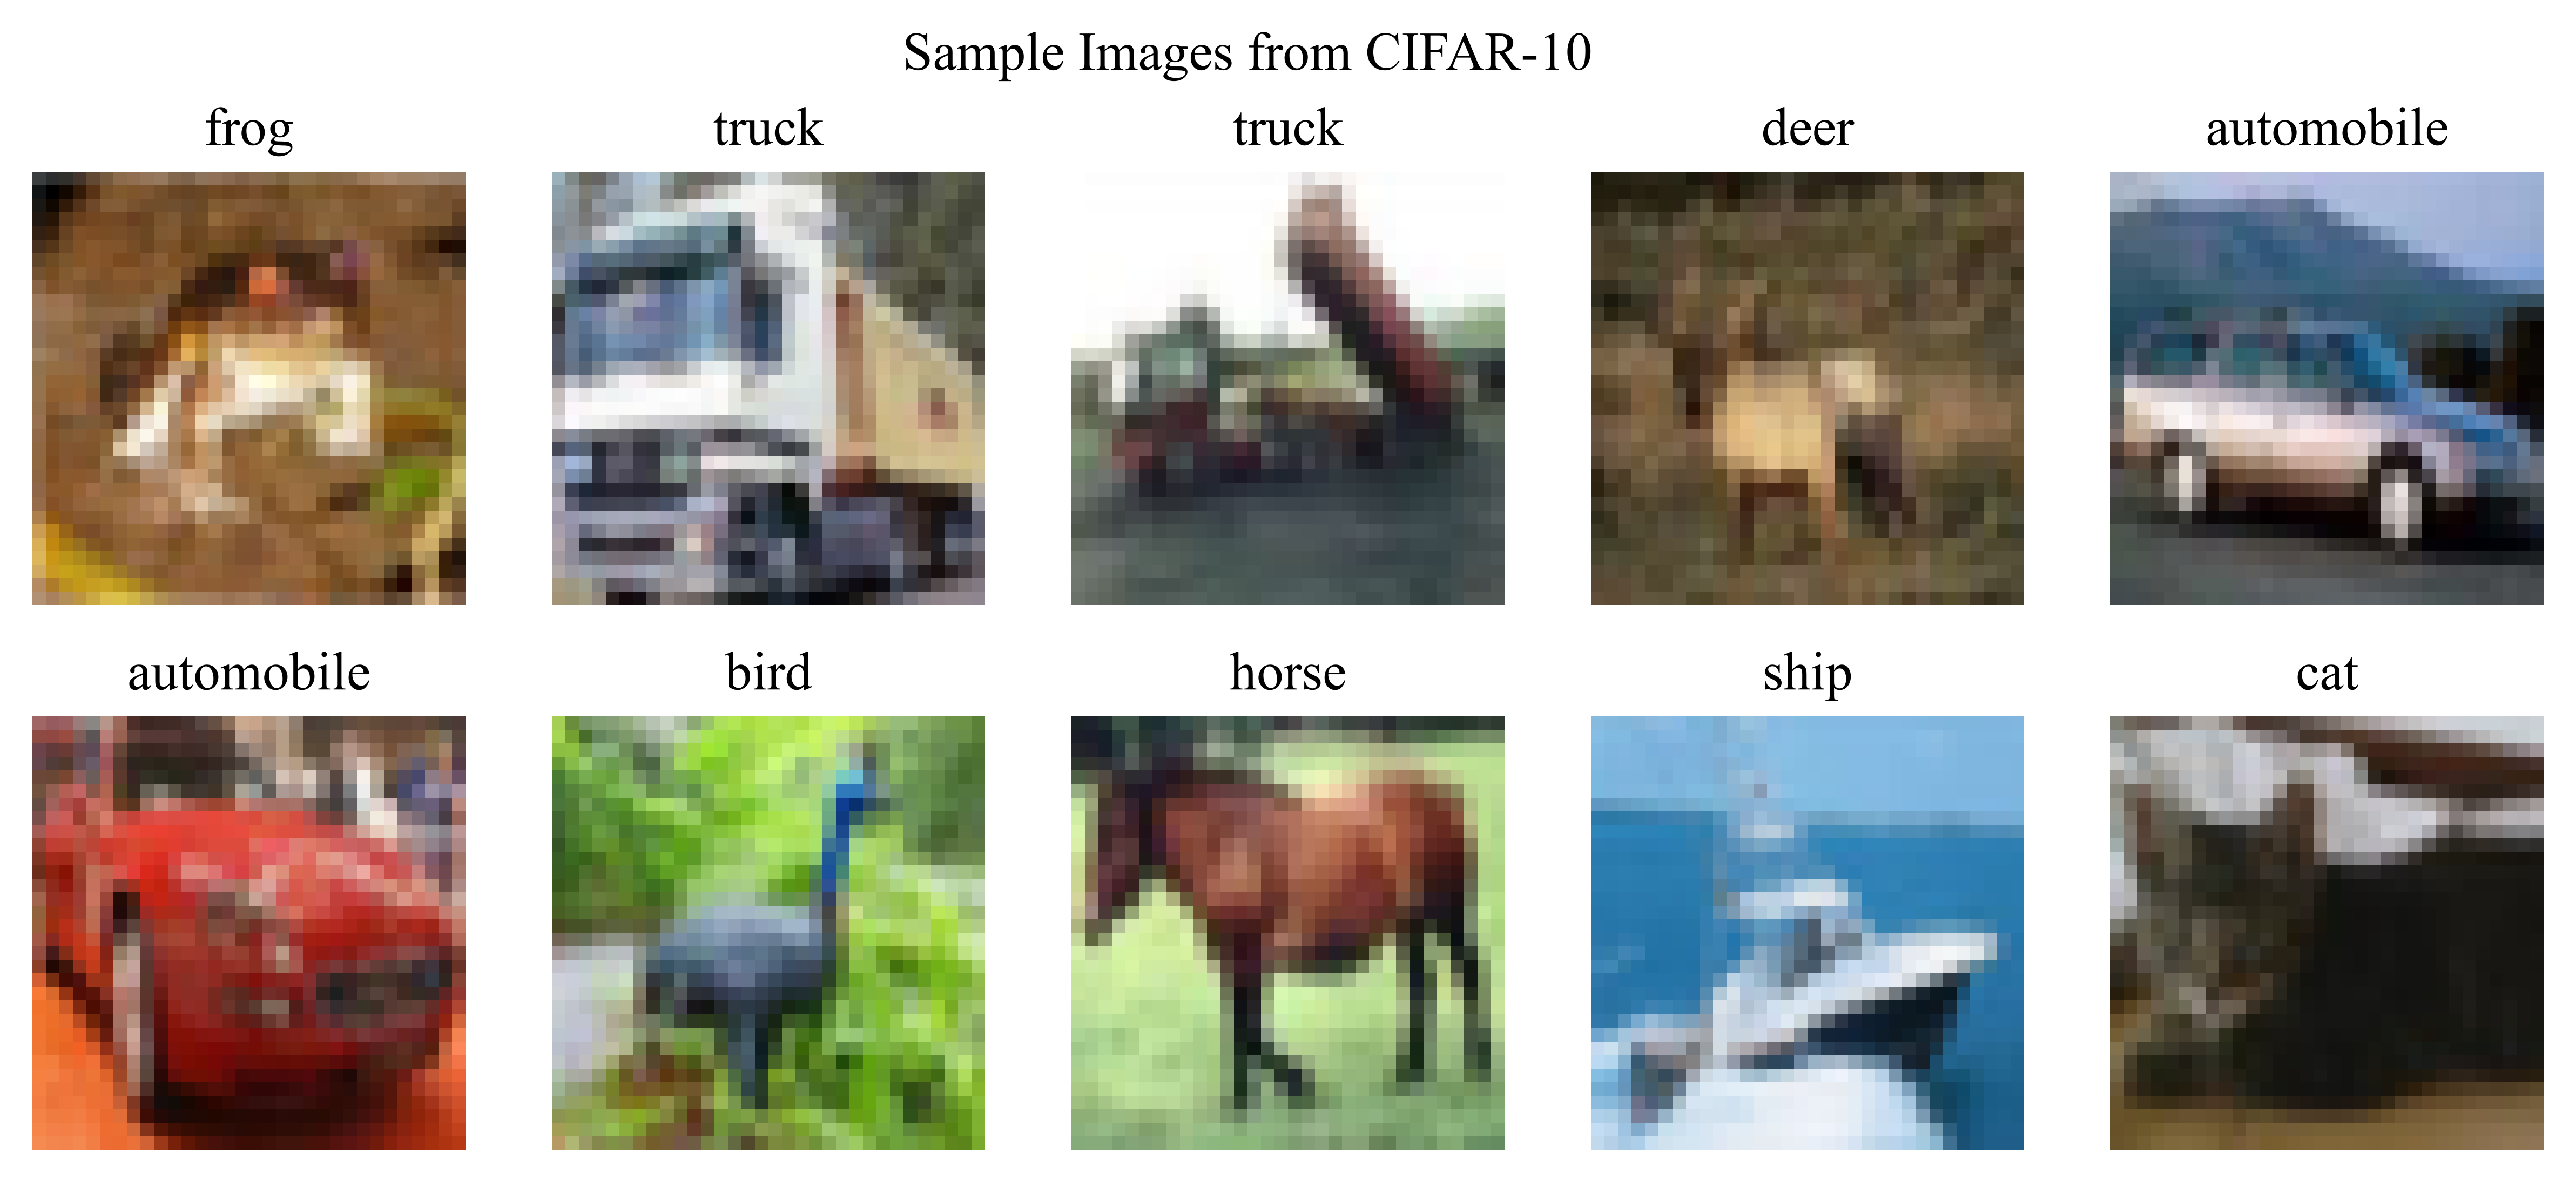

In [6]:
# displaying ten sample images with their class names
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_full[i])
    plt.title(class_names[int(y_train_full[i][0])])
    plt.axis('off')
plt.suptitle("Sample Images from CIFAR-10")
save_plot("sample_images")
plt.show()
 
# Inference: the dataset contains 32x32 colour images across 10 different
# categories, the images are quite small so some classes look visually similar.

saved class_distribution.eps


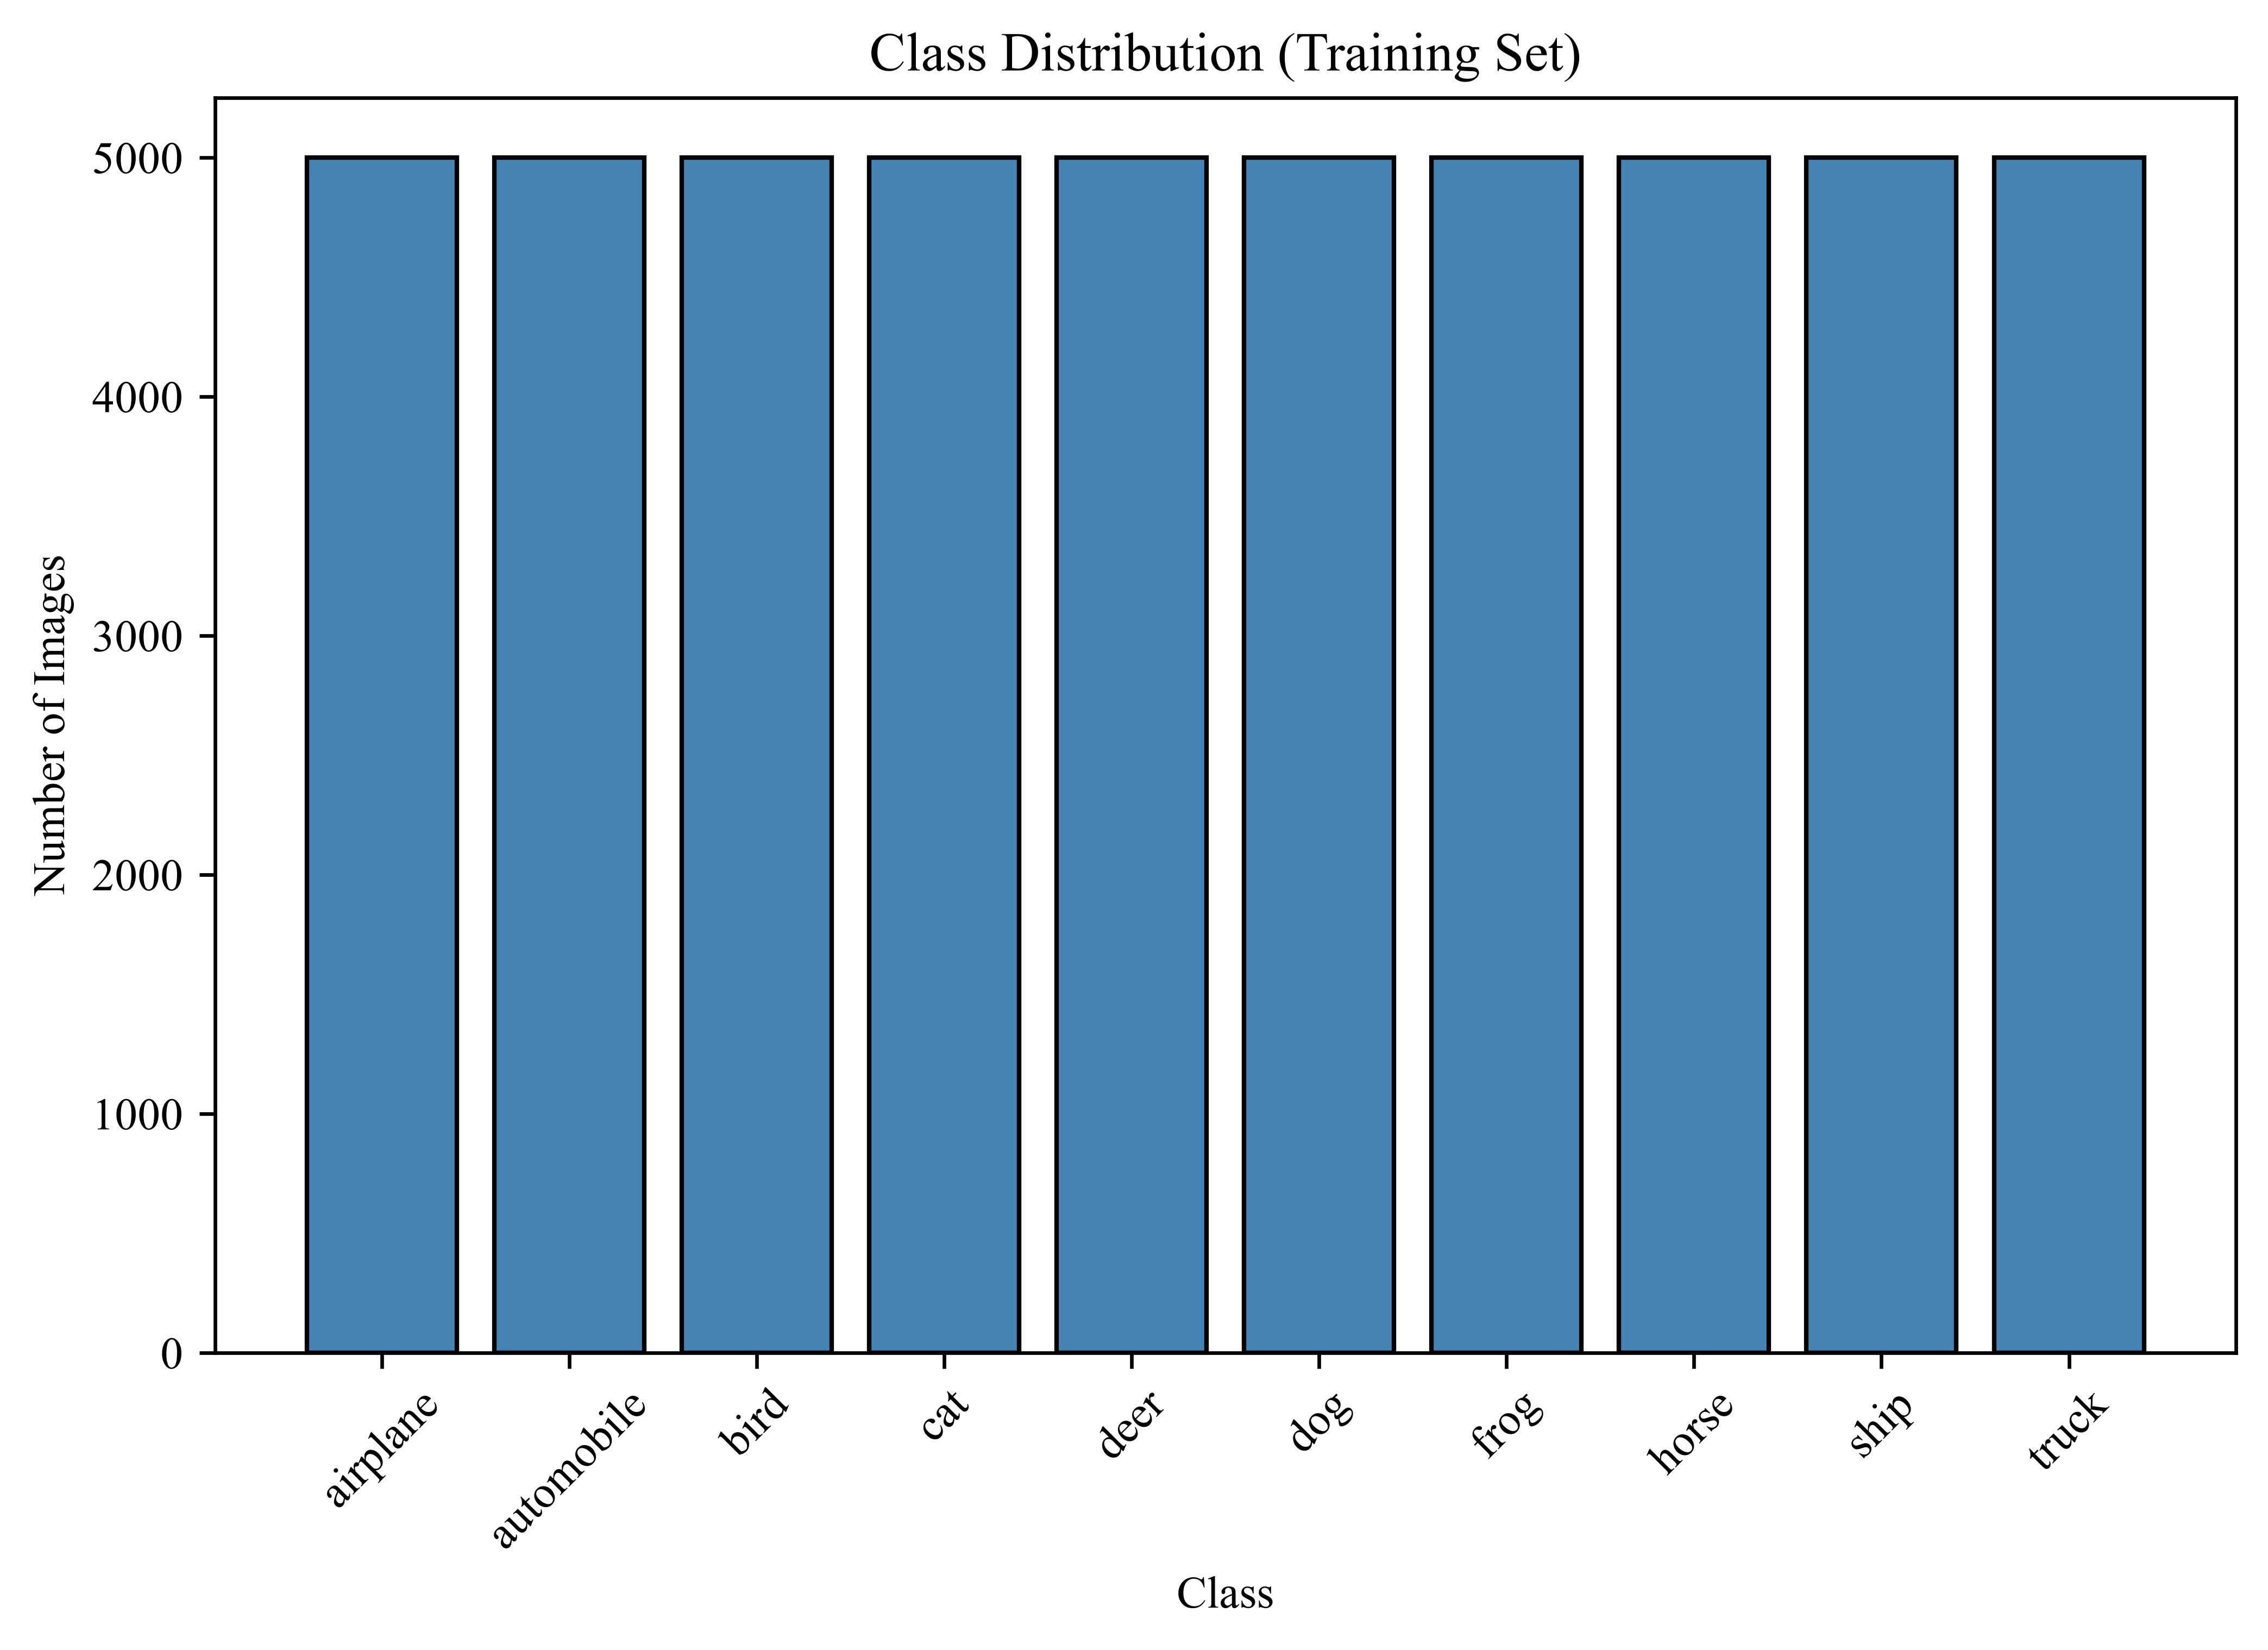

In [7]:
# plotting class distribution
classes, counts = np.unique(y_train_full, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar([class_names[c] for c in classes], counts, color='steelblue', edgecolor='black')
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution (Training Set)")
plt.xticks(rotation=45)
save_plot("class_distribution")
plt.show()

# Inference: all ten classes have an equal number of images (5000 each),
# so the dataset is perfectly balanced and no class weighting is needed.

In [8]:
# normalizing pixel values to [0,1] before feeding to any conv layer
X_train_norm = X_train_full.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

sample_img = X_train_norm[0:1]  # taking one sample image, shape (1,32,32,3)

kernel_sizes = [3, 5, 7]
print("Feature map sizes for different kernel sizes (stride=1, padding='valid'):")
for k in kernel_sizes:
    conv_layer = layers.Conv2D(filters=8, kernel_size=k, strides=1, padding='valid')
    output = conv_layer(sample_img)
    print(f"Kernel = {k}x{k} -> Output feature map shape: {output.shape[1:3]}")

# Inference: as the kernel size increases, the output feature map becomes
# smaller (with valid padding) because the filter has less room to slide
# across the image, larger kernels also capture more spatial context per step.


Feature map sizes for different kernel sizes (stride=1, padding='valid'):
Kernel = 3x3 -> Output feature map shape: (30, 30)
Kernel = 5x5 -> Output feature map shape: (28, 28)
Kernel = 7x7 -> Output feature map shape: (26, 26)


In [9]:
strides_to_check = [1, 2]
paddings_to_check = ['same', 'valid']

print("Feature map sizes for different stride/padding combinations (kernel=3x3):")
for s in strides_to_check:
    for p in paddings_to_check:
        conv_layer = layers.Conv2D(filters=8, kernel_size=3, strides=s, padding=p)
        output = conv_layer(sample_img)
        print(f"Stride = {s}, Padding = {p} -> Output shape: {output.shape[1:3]}")

Feature map sizes for different stride/padding combinations (kernel=3x3):
Stride = 1, Padding = same -> Output shape: (32, 32)
Stride = 1, Padding = valid -> Output shape: (30, 30)
Stride = 2, Padding = same -> Output shape: (16, 16)
Stride = 2, Padding = valid -> Output shape: (15, 15)


In [10]:
# verifying manually using the formula (N - F + 2P) / S + 1
def compute_output_size(N, F, P, S):
    return int((N - F + 2 * P) / S) + 1

# for kernel=3, 'same' padding means P=1, 'valid' padding means P=0
print("Manual calculation check:")
print("Stride=1, same  ->", compute_output_size(32, 3, 1, 1))
print("Stride=1, valid ->", compute_output_size(32, 3, 0, 1))
print("Stride=2, same  ->", compute_output_size(32, 3, 1, 2))
print("Stride=2, valid ->", compute_output_size(32, 3, 0, 2))

# Inference: 'same' padding keeps the output size equal to the input size
# when stride=1, while 'valid' padding shrinks the output. Increasing the
# stride reduces the output size further because the filter skips positions
# while sliding over the image.

Manual calculation check:
Stride=1, same  -> 32
Stride=1, valid -> 30
Stride=2, same  -> 16
Stride=2, valid -> 15


In [11]:
# building just the first conv layer to visualize what it learns/extracts
feature_map_model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3))
])

feature_maps = feature_map_model.predict(sample_img)
print("Feature maps shape:", feature_maps.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

c:\Users\Kishore\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Feature maps shape: (1, 32, 32, 16)


saved feature_maps.eps


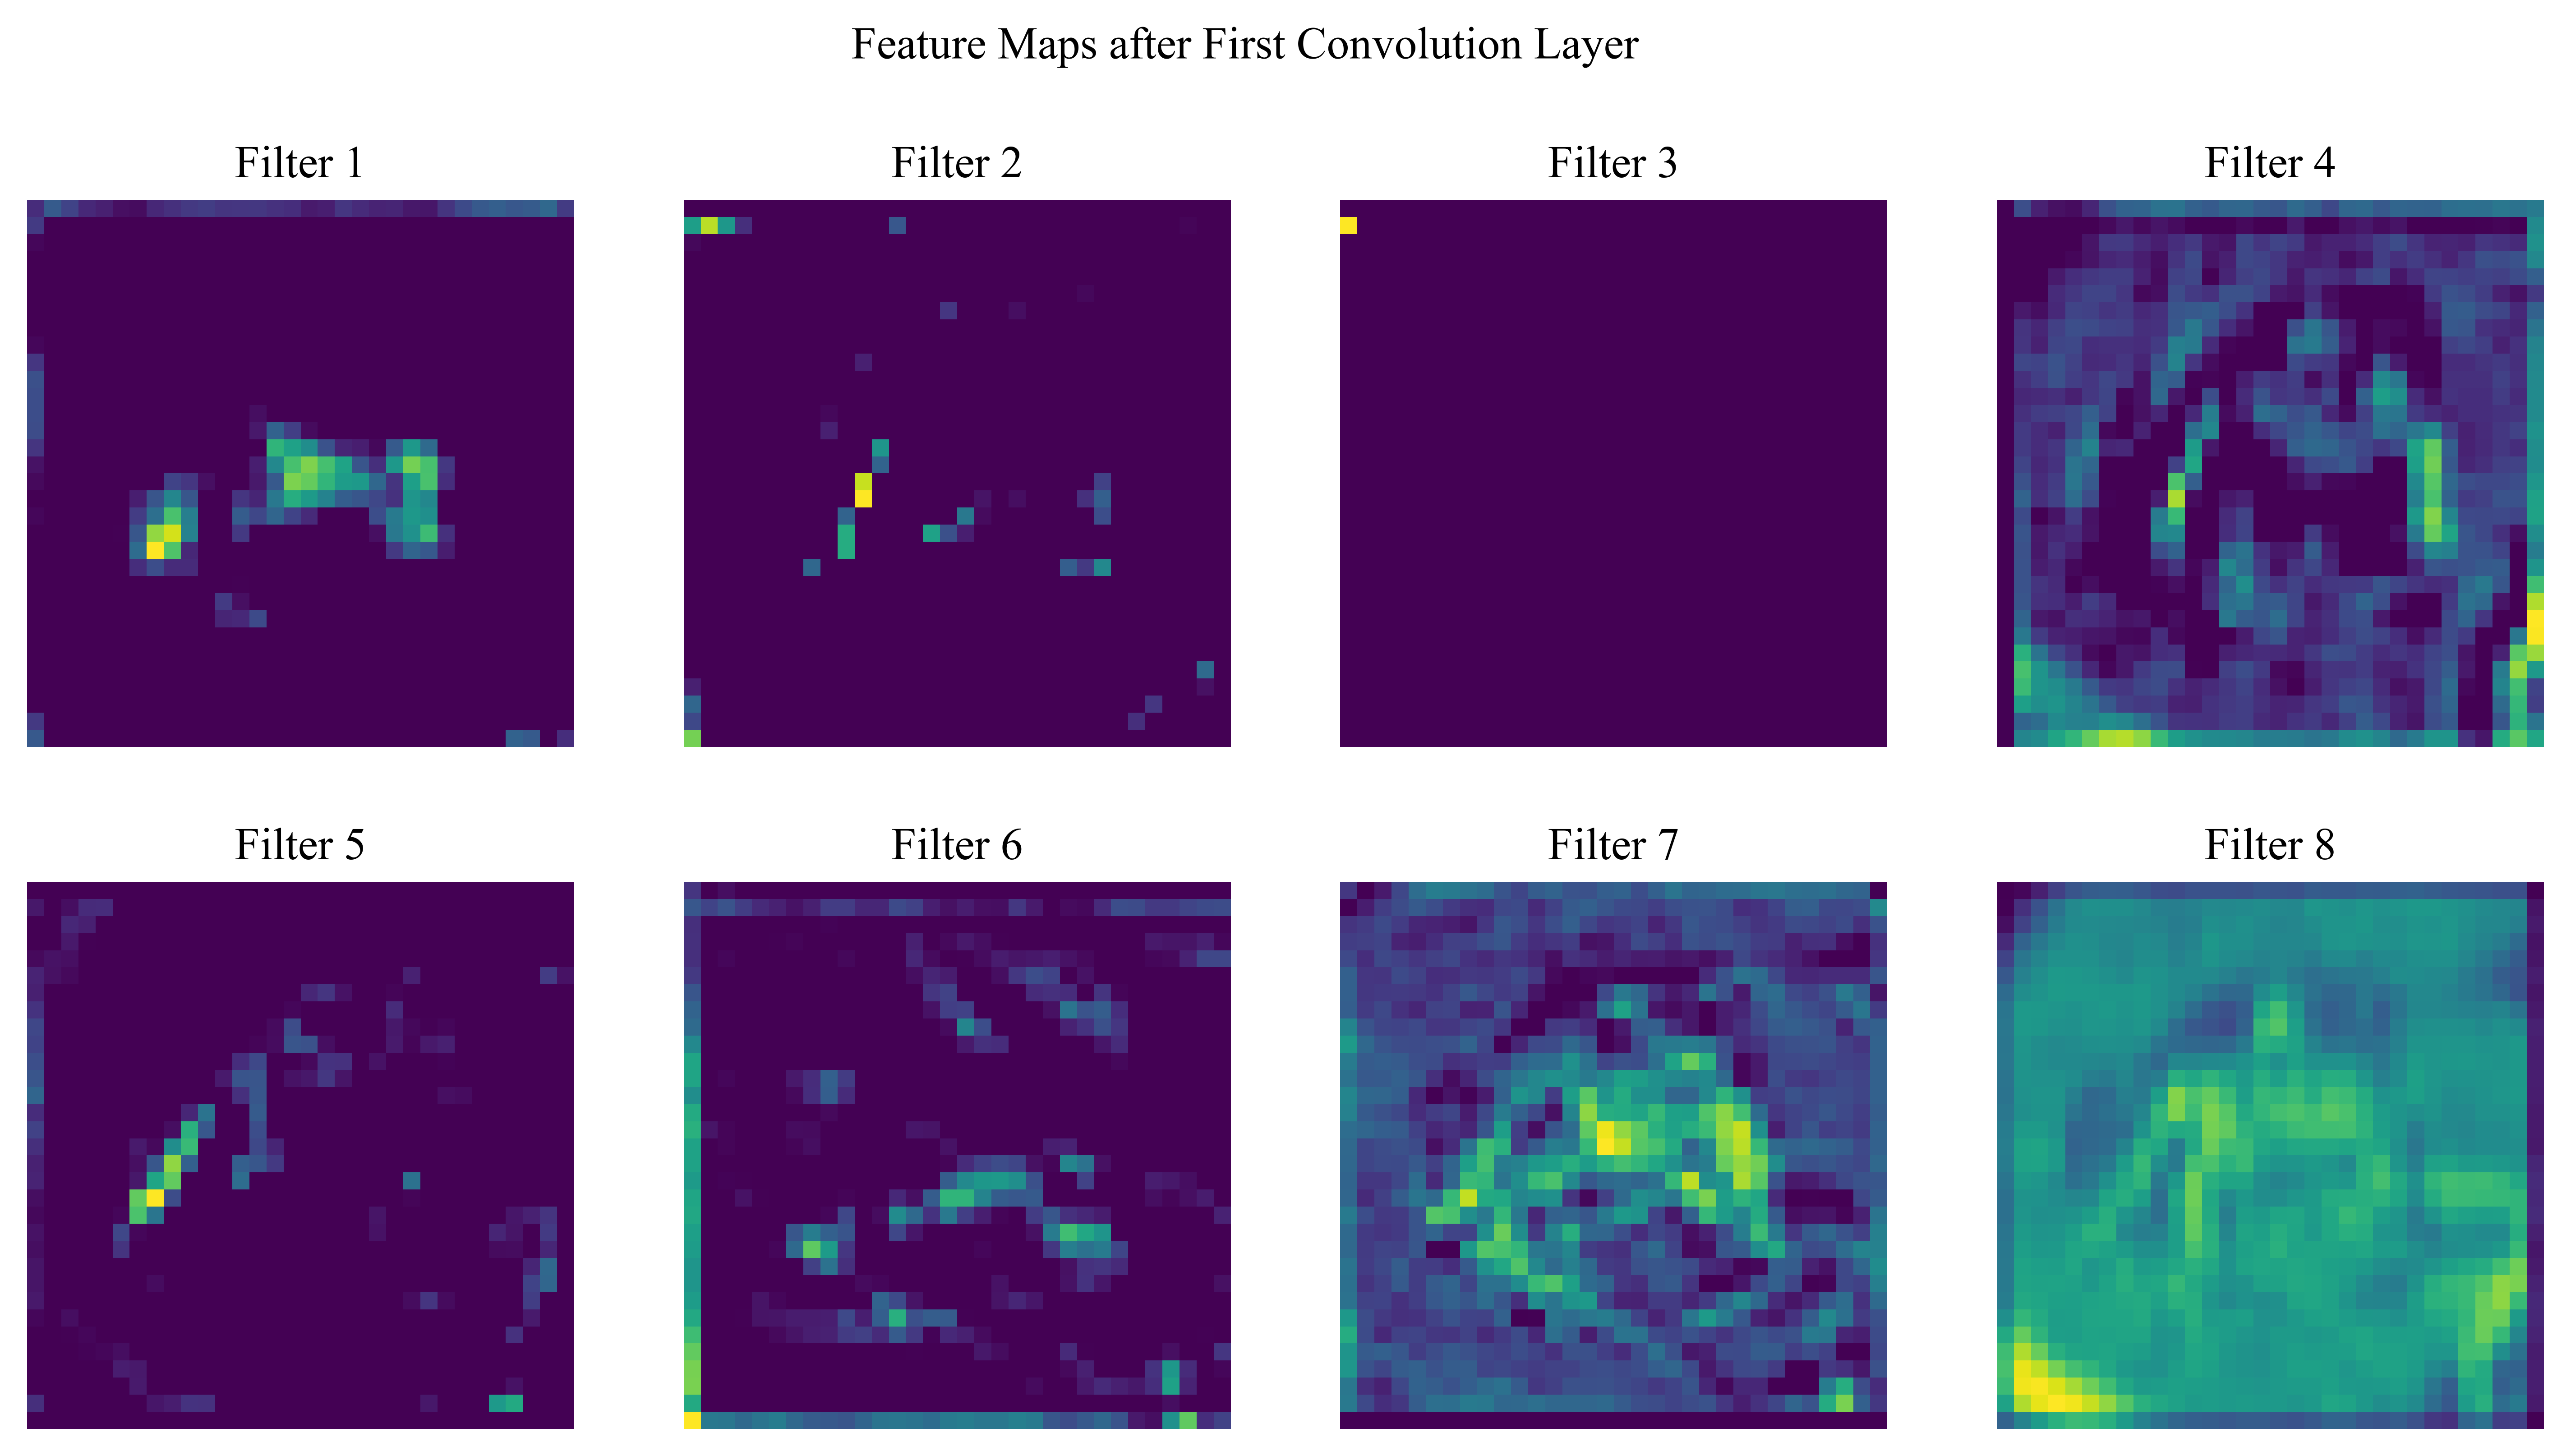

In [12]:
# displaying at least 8 feature maps
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.title(f"Filter {i+1}")
    plt.axis('off')
plt.suptitle("Feature Maps after First Convolution Layer")
save_plot("feature_maps")
plt.show()

# Inference: each filter in the first conv layer responds to different
# low level patterns in the image such as edges, colour blobs and textures,
# some filters activate strongly on object boundaries while others stay flat.


In [13]:
max_pool_layer = layers.MaxPooling2D(pool_size=(2, 2))
avg_pool_layer = layers.AveragePooling2D(pool_size=(2, 2))

max_pooled = max_pool_layer(feature_maps)
avg_pooled = avg_pool_layer(feature_maps)

print("Feature map shape before pooling :", feature_maps.shape)
print("Feature map shape after max pool :", max_pooled.shape)
print("Feature map shape after avg pool :", avg_pooled.shape)


Feature map shape before pooling : (1, 32, 32, 16)
Feature map shape after max pool : (1, 16, 16, 16)
Feature map shape after avg pool : (1, 16, 16, 16)


saved pooling_comparison.eps


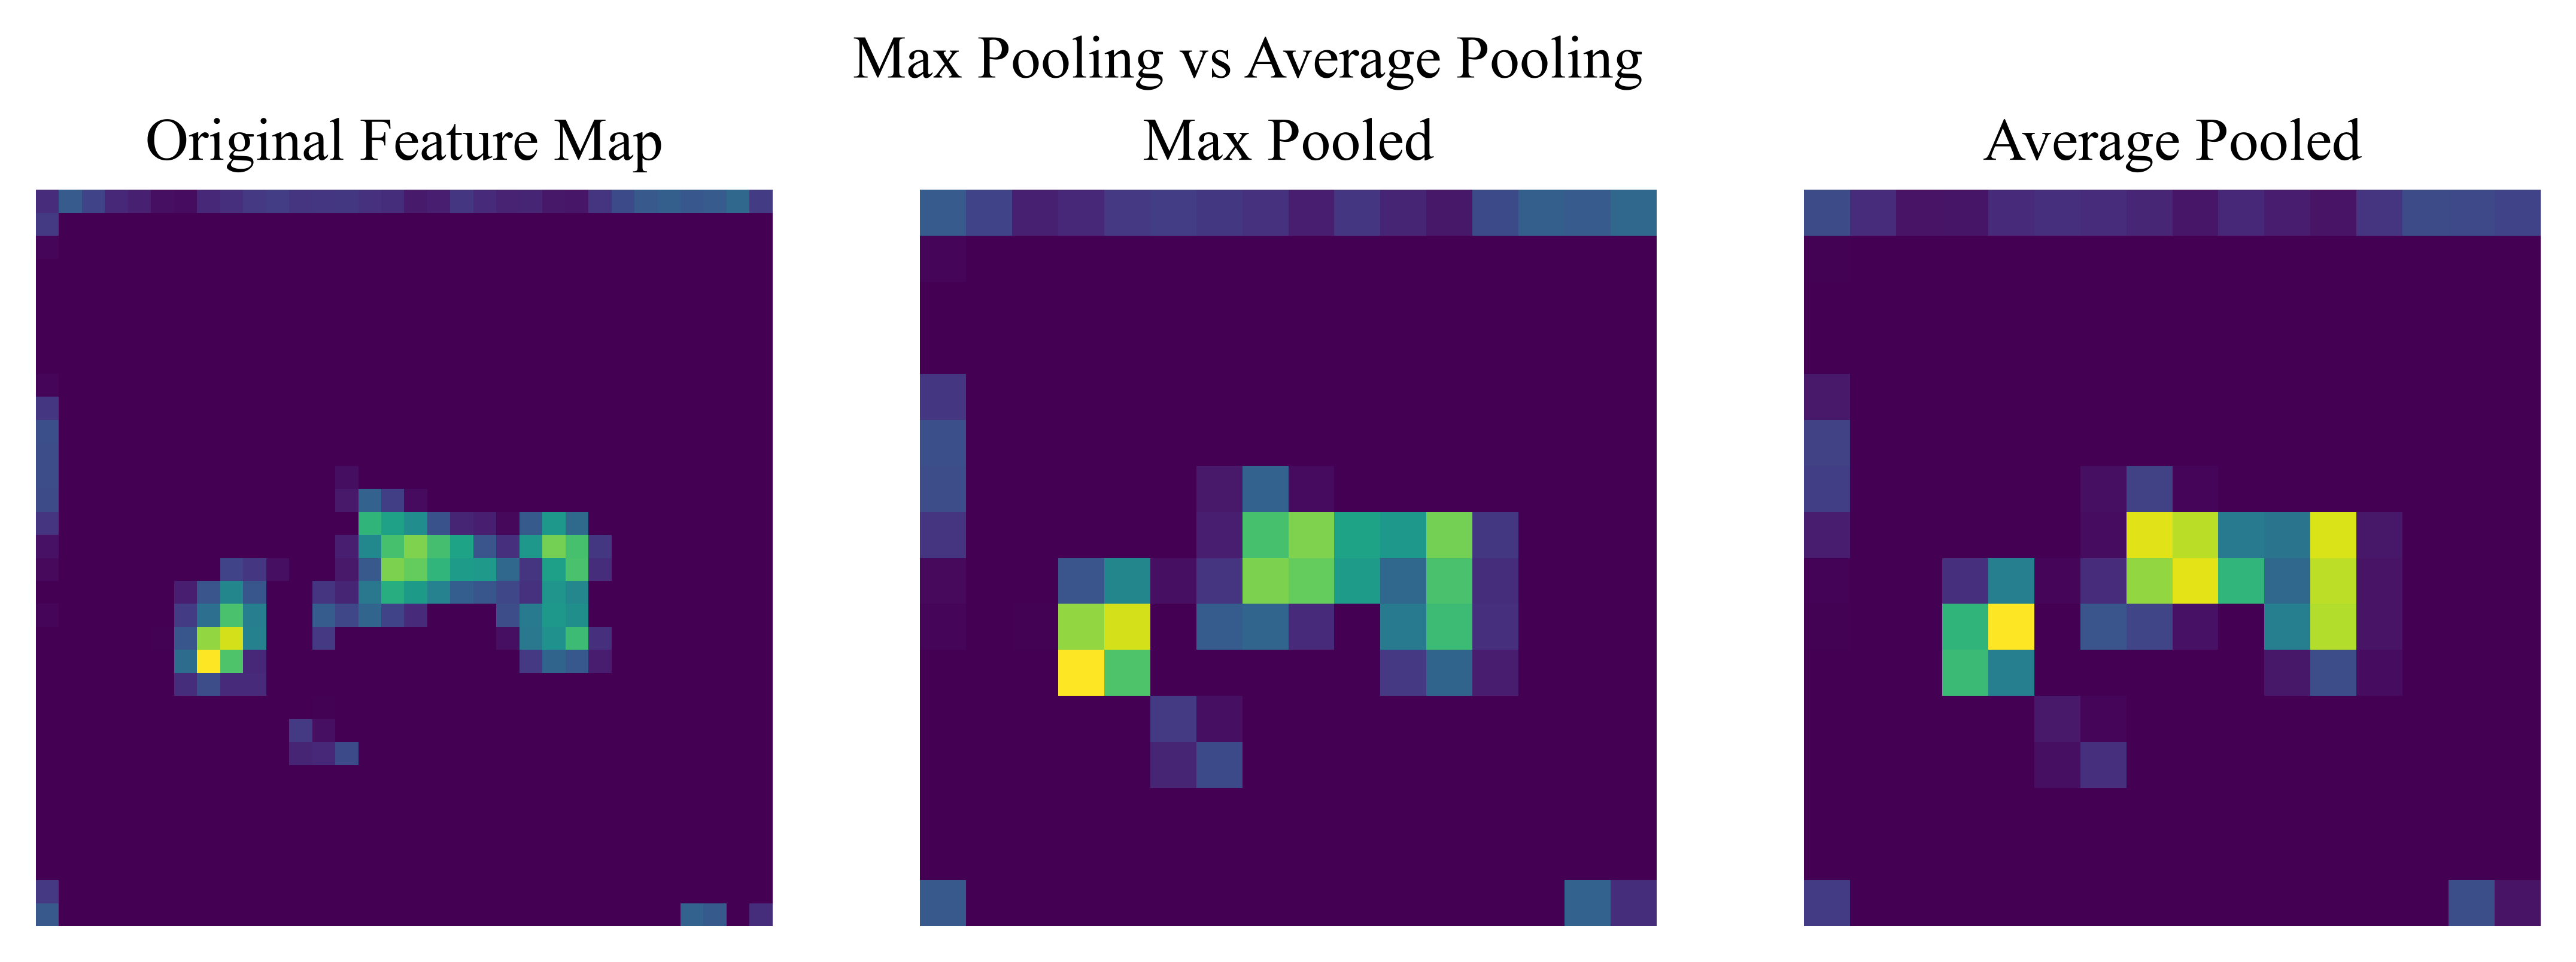

In [14]:
# visually comparing max pooling and average pooling on one filter
plt.figure(figsize=(9, 3))
plt.subplot(1, 3, 1)
plt.imshow(feature_maps[0, :, :, 0], cmap='viridis')
plt.title("Original Feature Map")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(max_pooled[0, :, :, 0], cmap='viridis')
plt.title("Max Pooled")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(avg_pooled[0, :, :, 0], cmap='viridis')
plt.title("Average Pooled")
plt.axis('off')

plt.suptitle("Max Pooling vs Average Pooling")
save_plot("pooling_comparison")
plt.show()

# Inference: max pooling keeps the strongest activations and preserves
# sharp features like edges better, while average pooling smooths the
# feature map out, both reduce the spatial size by half in this example.

In [18]:
# one hot encoding the labels for training
y_train_cat = to_categorical(y_train_full, 10)
y_test_cat = to_categorical(y_test, 10)


In [19]:
# building the CNN as specified in the lab manual
# Input -> Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Softmax
model = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(X_train_norm, y_train_cat,
                     epochs=20,
                     batch_size=32,
                     validation_data=(X_test_norm, y_test_cat))


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5157 - loss: 1.3550 - val_accuracy: 0.6260 - val_loss: 1.0740
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6529 - loss: 0.9914 - val_accuracy: 0.6721 - val_loss: 0.9418
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6986 - loss: 0.8600 - val_accuracy: 0.6733 - val_loss: 0.9390
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7336 - loss: 0.7678 - val_accuracy: 0.6966 - val_loss: 0.8861
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7633 - loss: 0.6793 - val_accuracy: 0.6979 - val_loss: 0.8844
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7876 - loss: 0.6028 - val_accuracy: 0.7076 - val_loss: 0.8644
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8132 - loss: 0.5314 - val_accuracy: 0.7034 - val_loss: 0.9259
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8328 - loss: 0

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved training_accuracy.eps


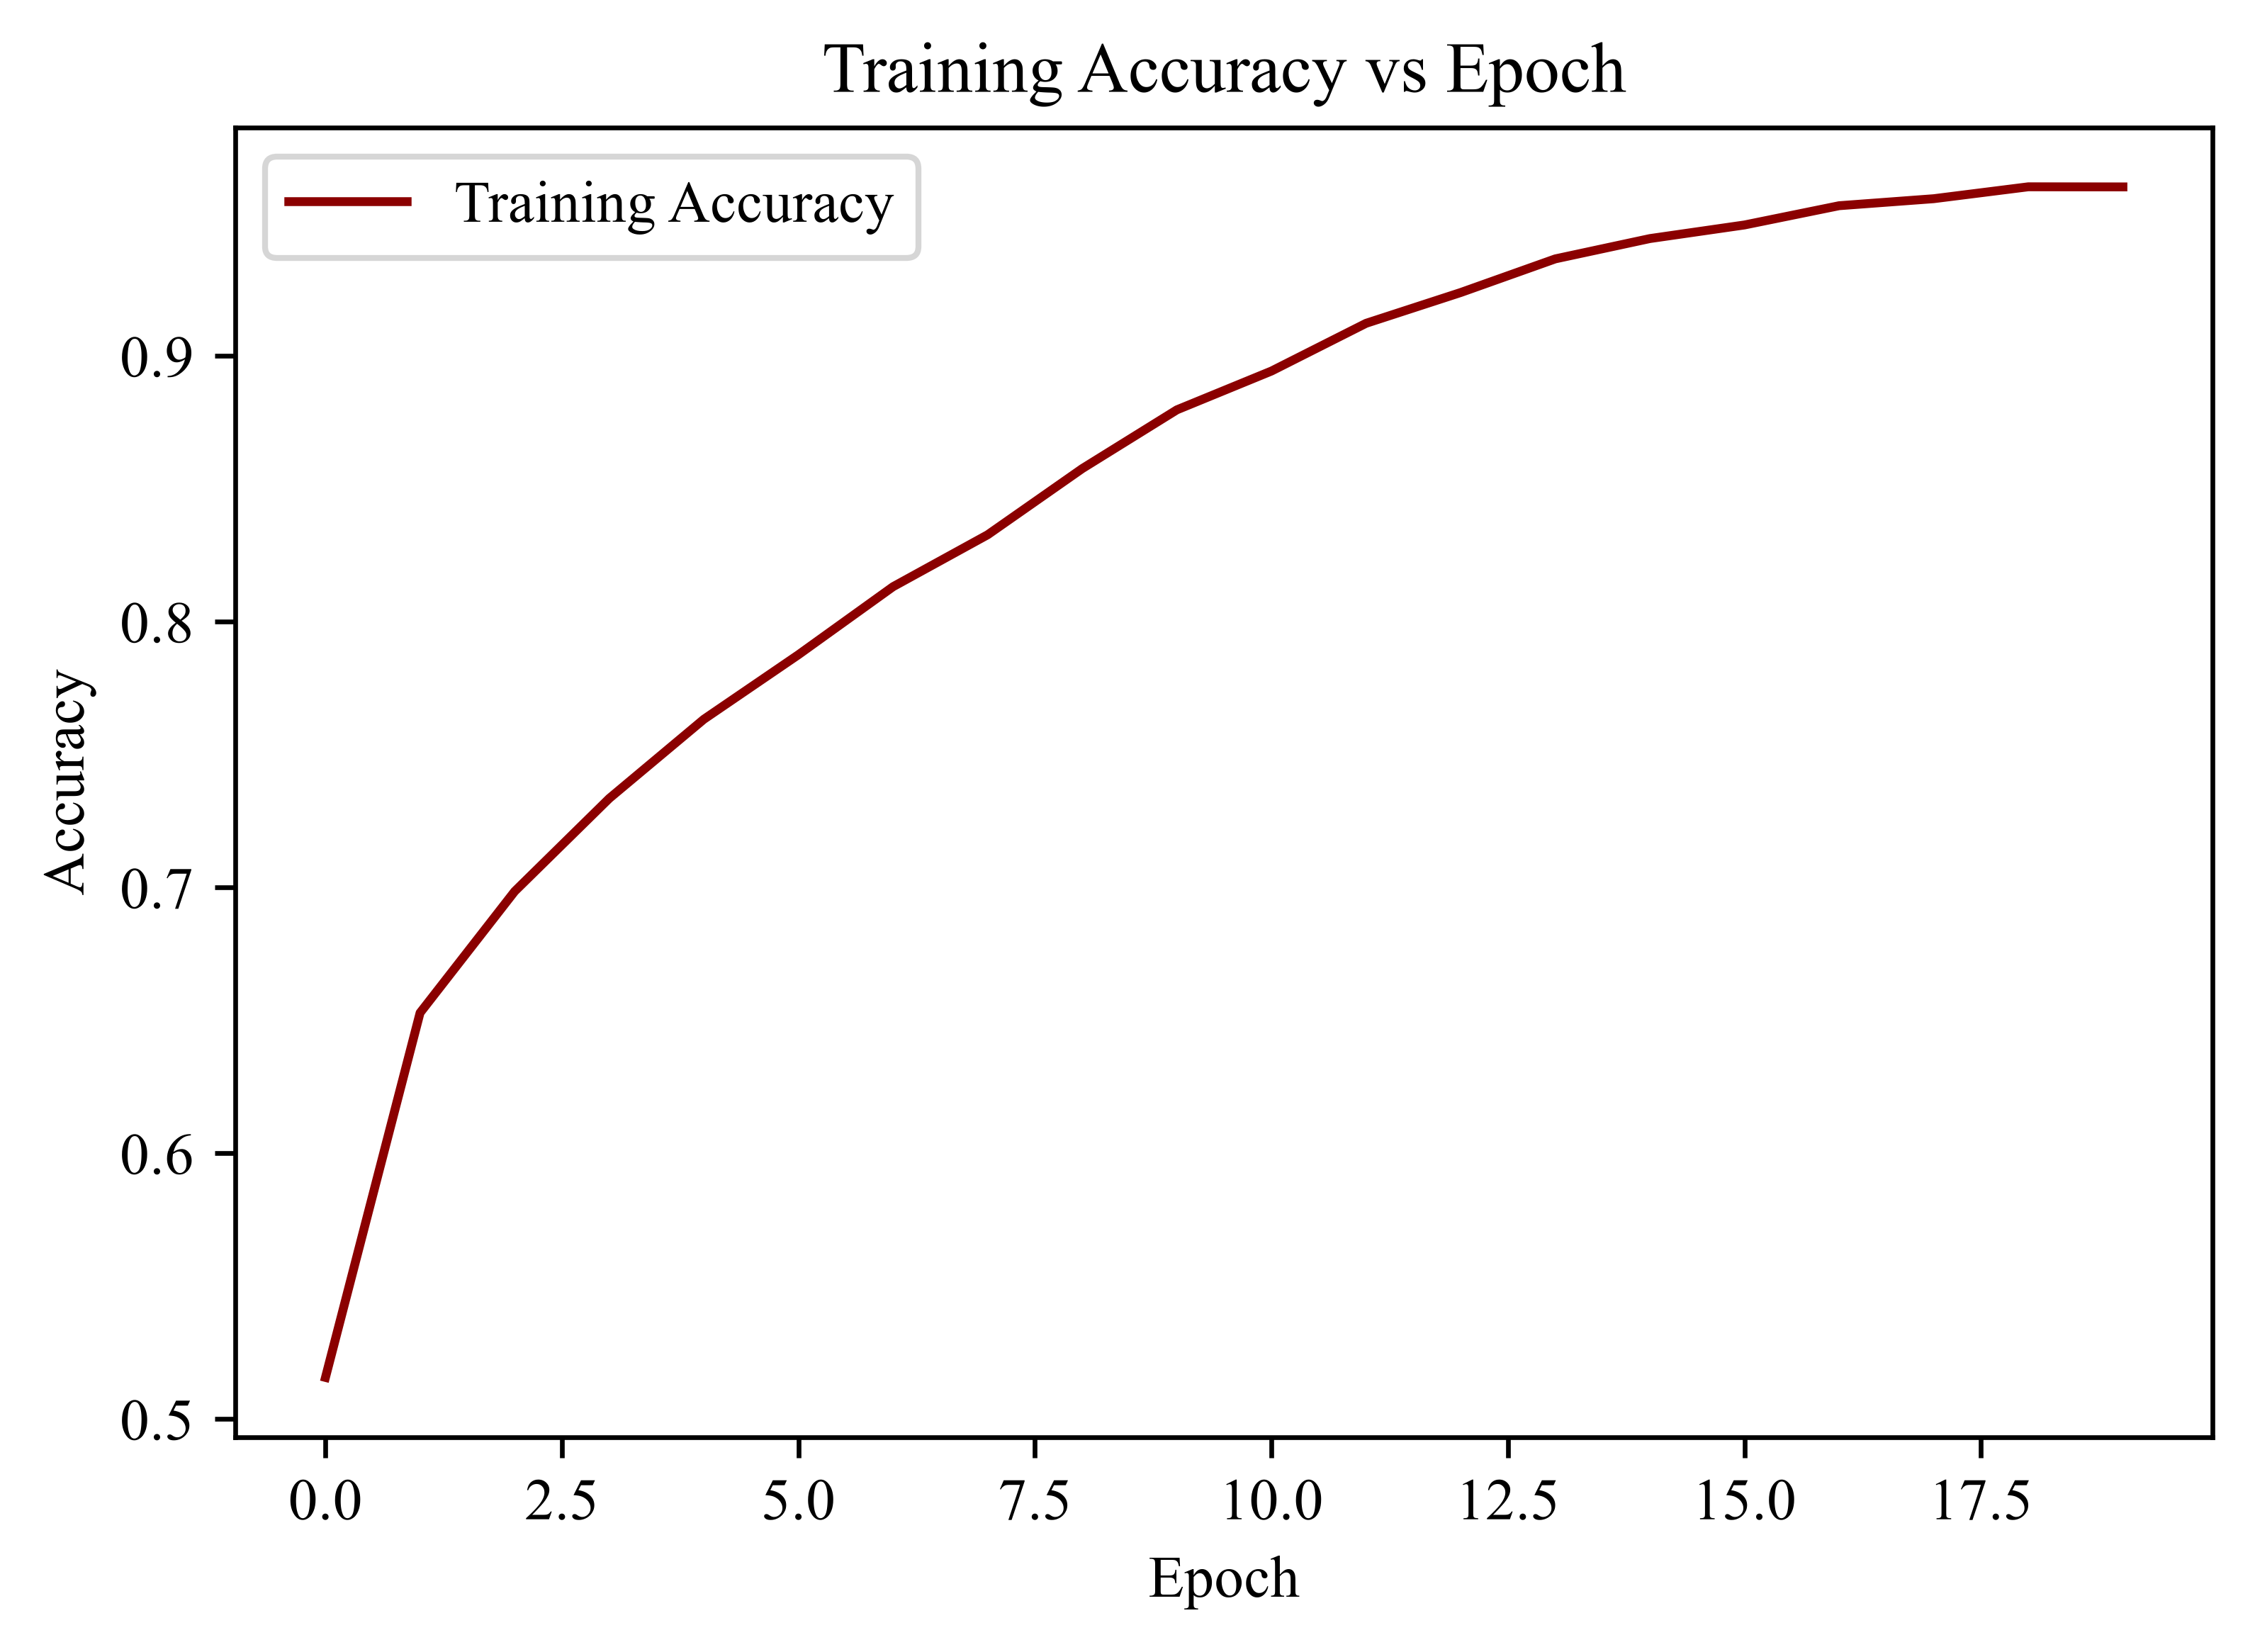

In [21]:
# training vs validation accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='darkred')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.legend()
save_plot("training_accuracy")
plt.show()

# Inference: training accuracy steadily increases across epochs, showing
# that the model is learning to fit the training data well as it trains.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved validation_accuracy.eps


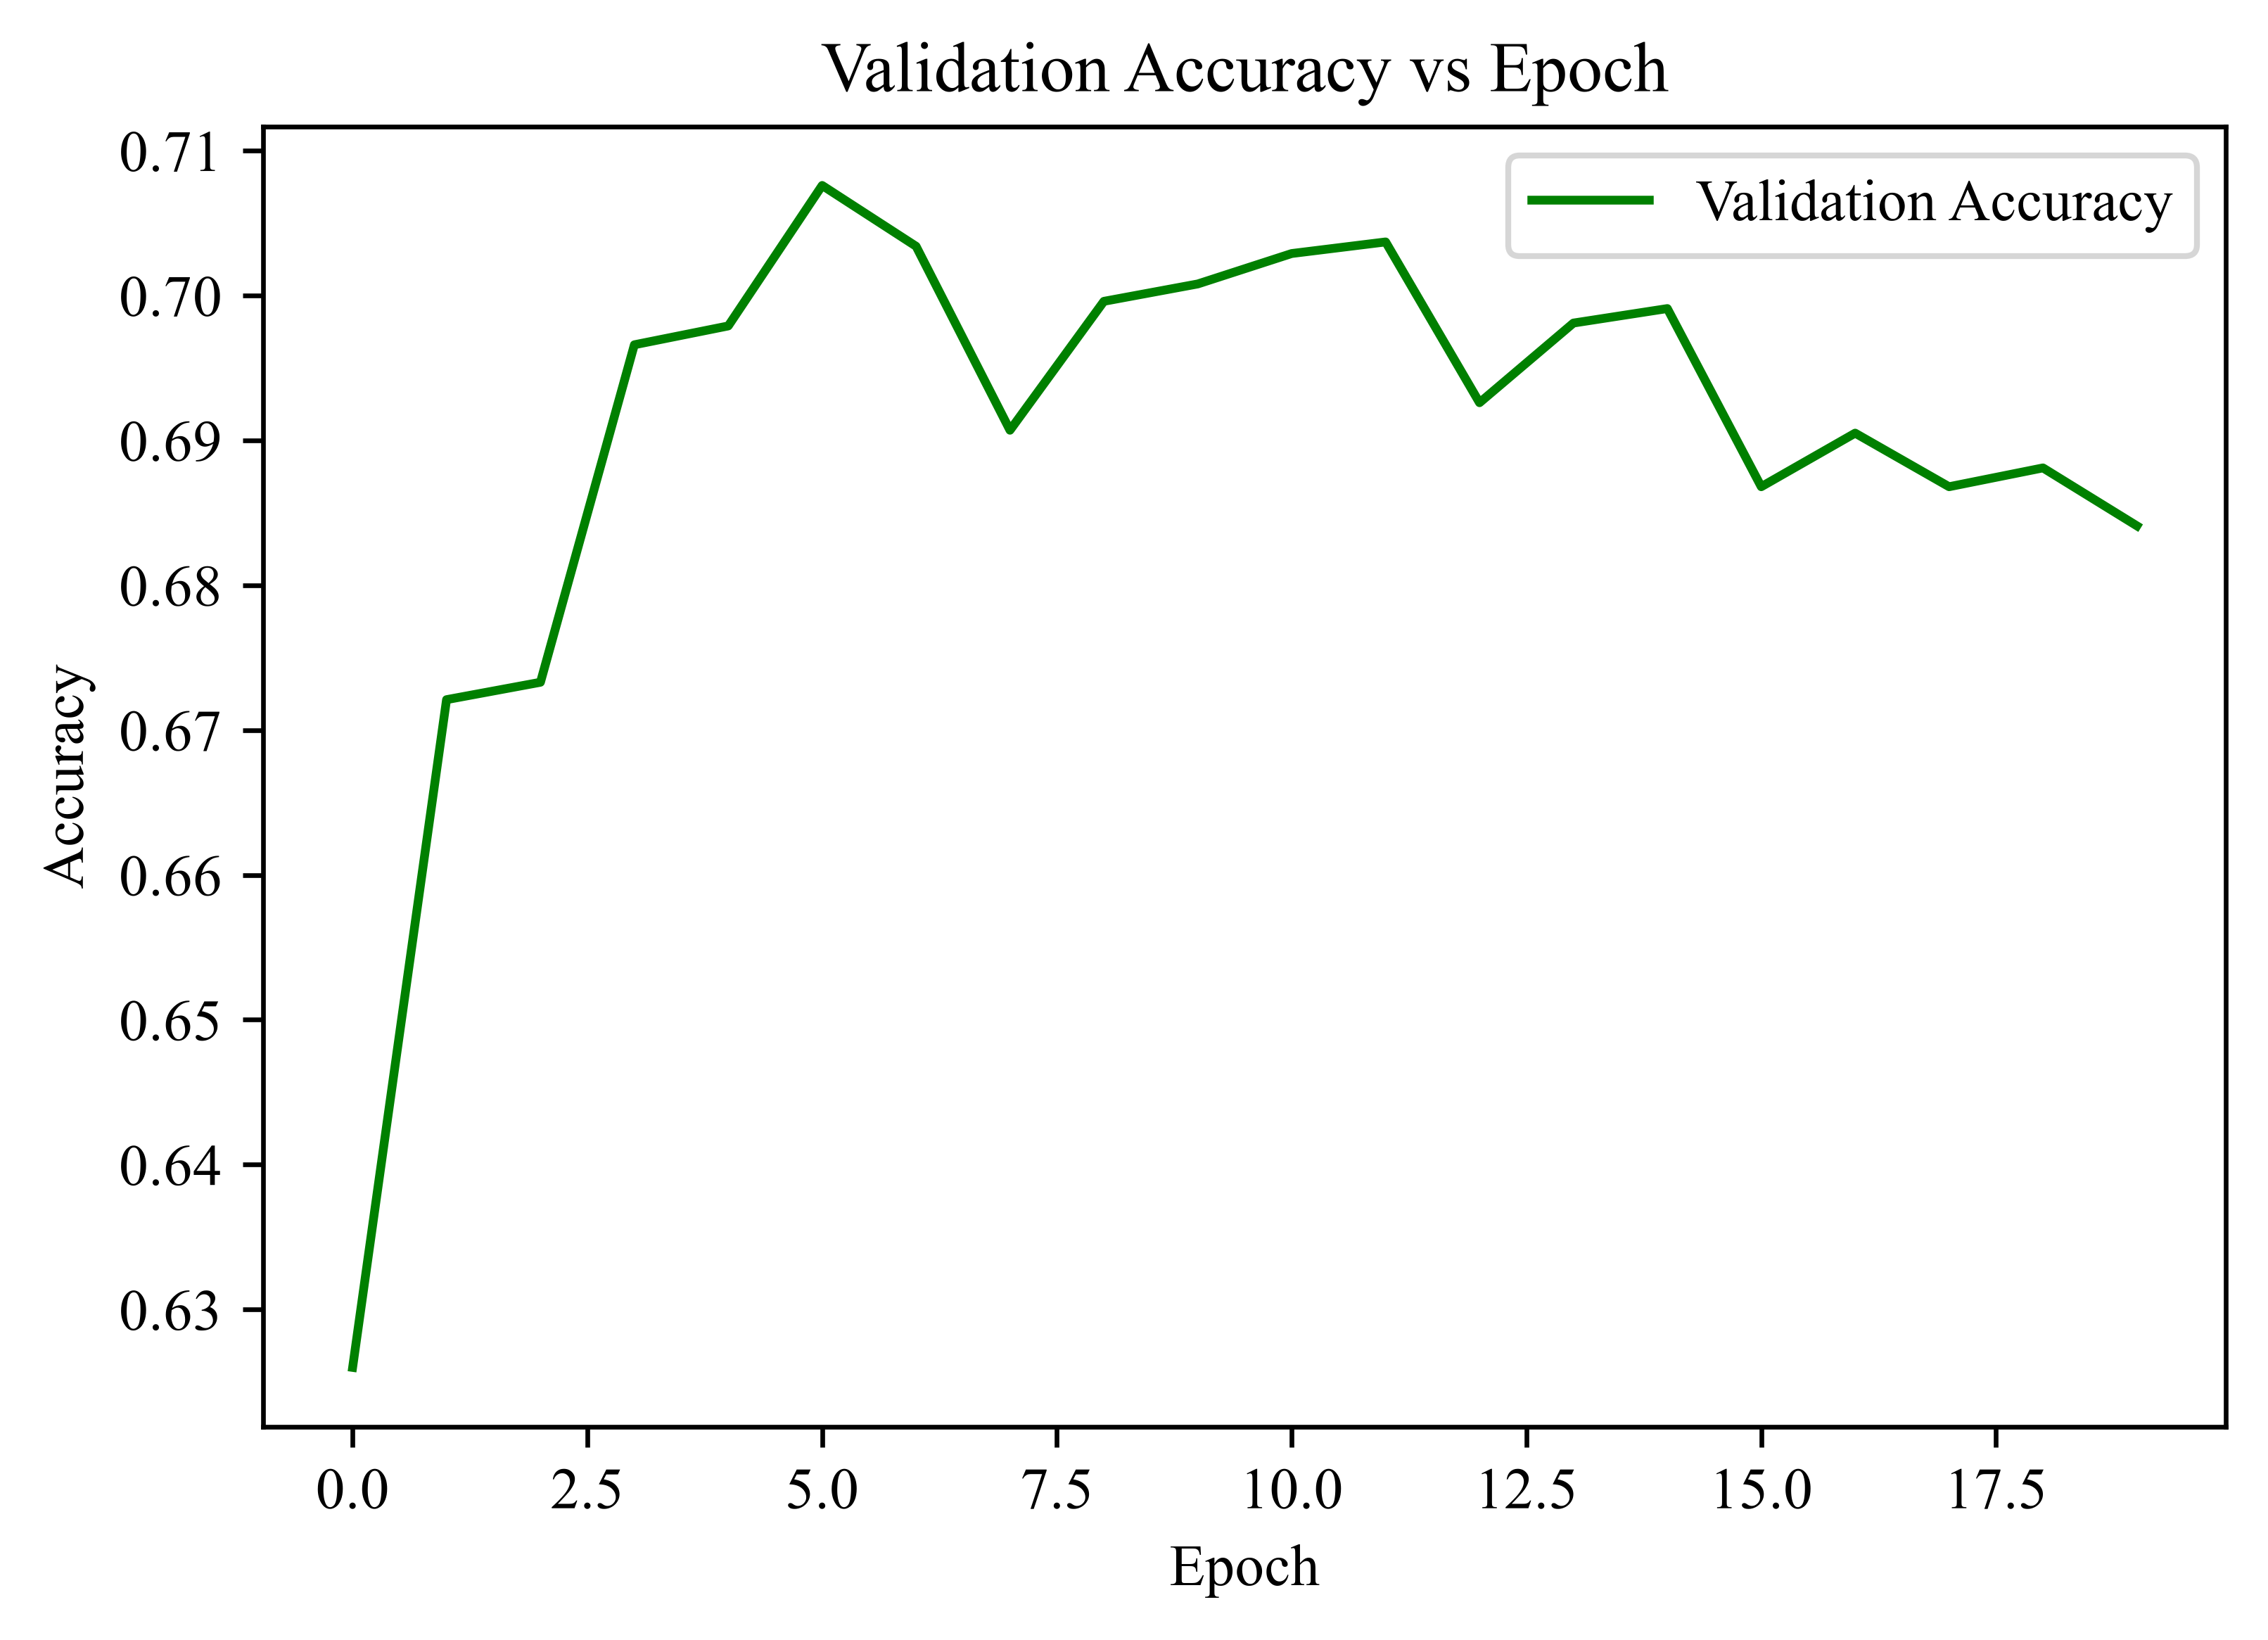

In [22]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.legend()
save_plot("validation_accuracy")
plt.show()

# Inference: validation accuracy also improves with epochs but at a slower
# rate than training accuracy, if it plateaus or drops it would suggest
# the model is starting to overfit.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved training_loss.eps


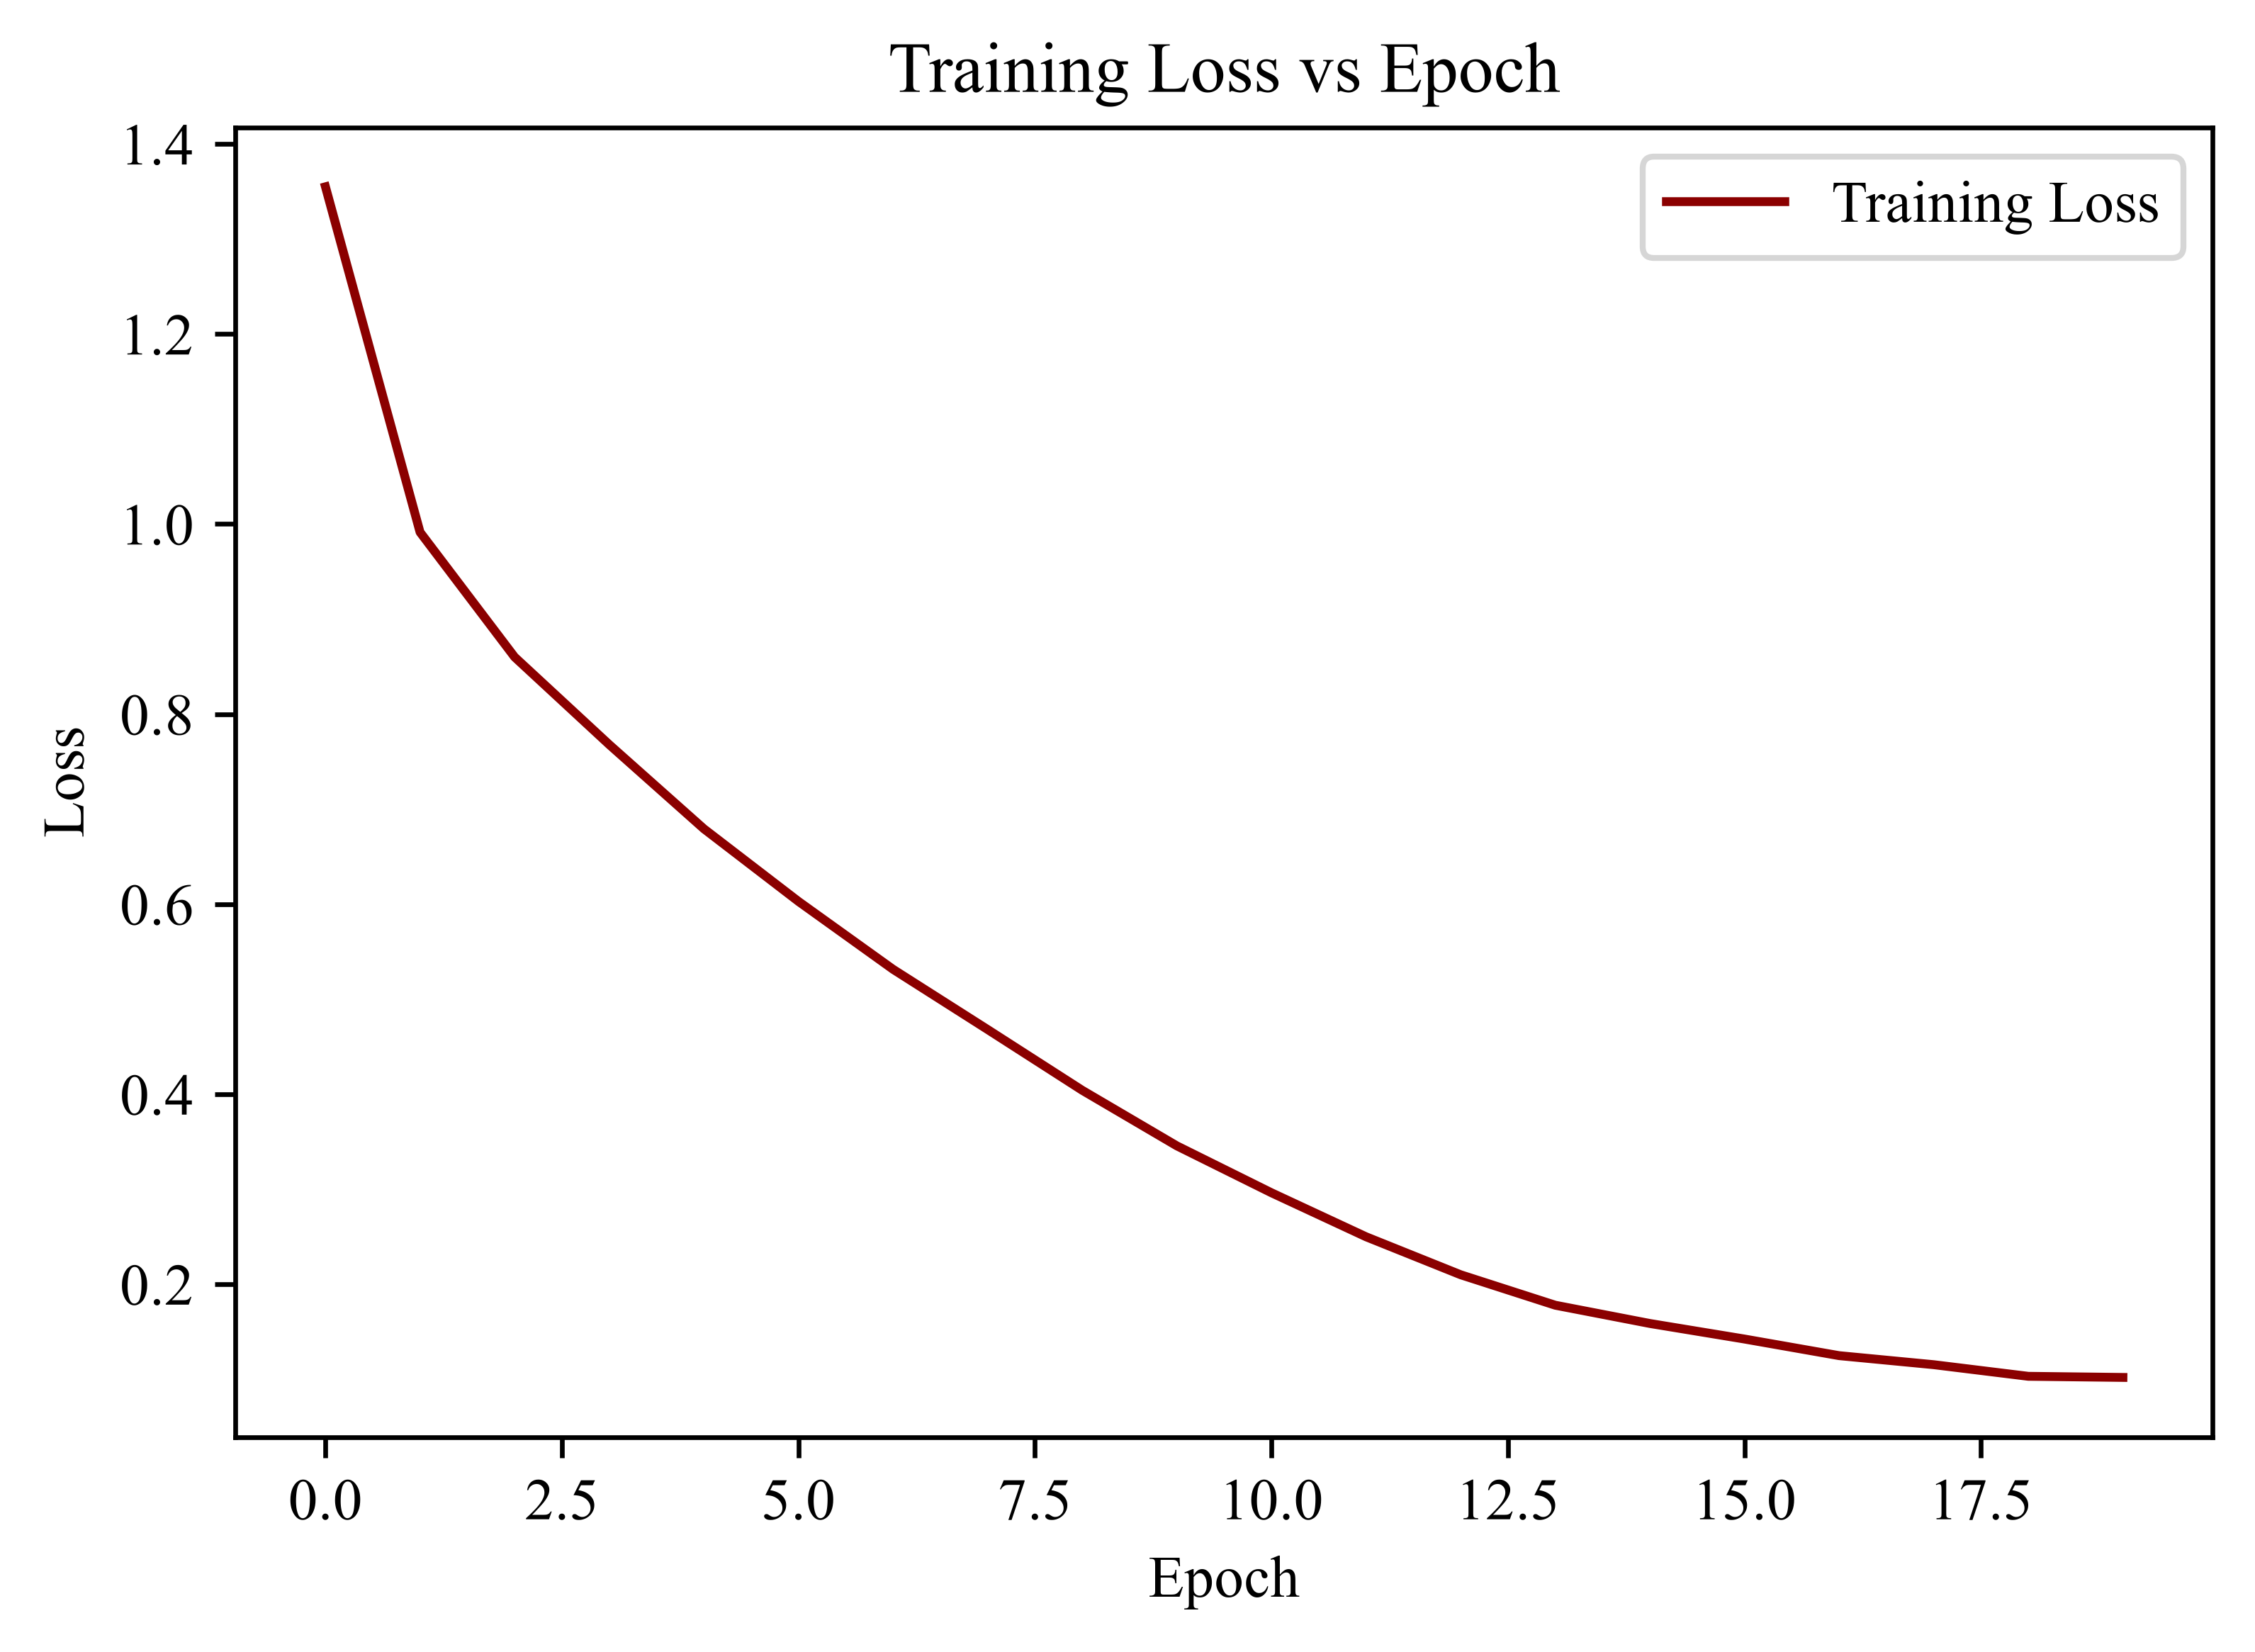

In [23]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss', color='darkred')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.legend()
save_plot("training_loss")
plt.show()

# Inference: training loss decreases consistently over epochs, confirming
# that the optimizer is minimizing the categorical crossentropy loss well.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved validation_loss.eps


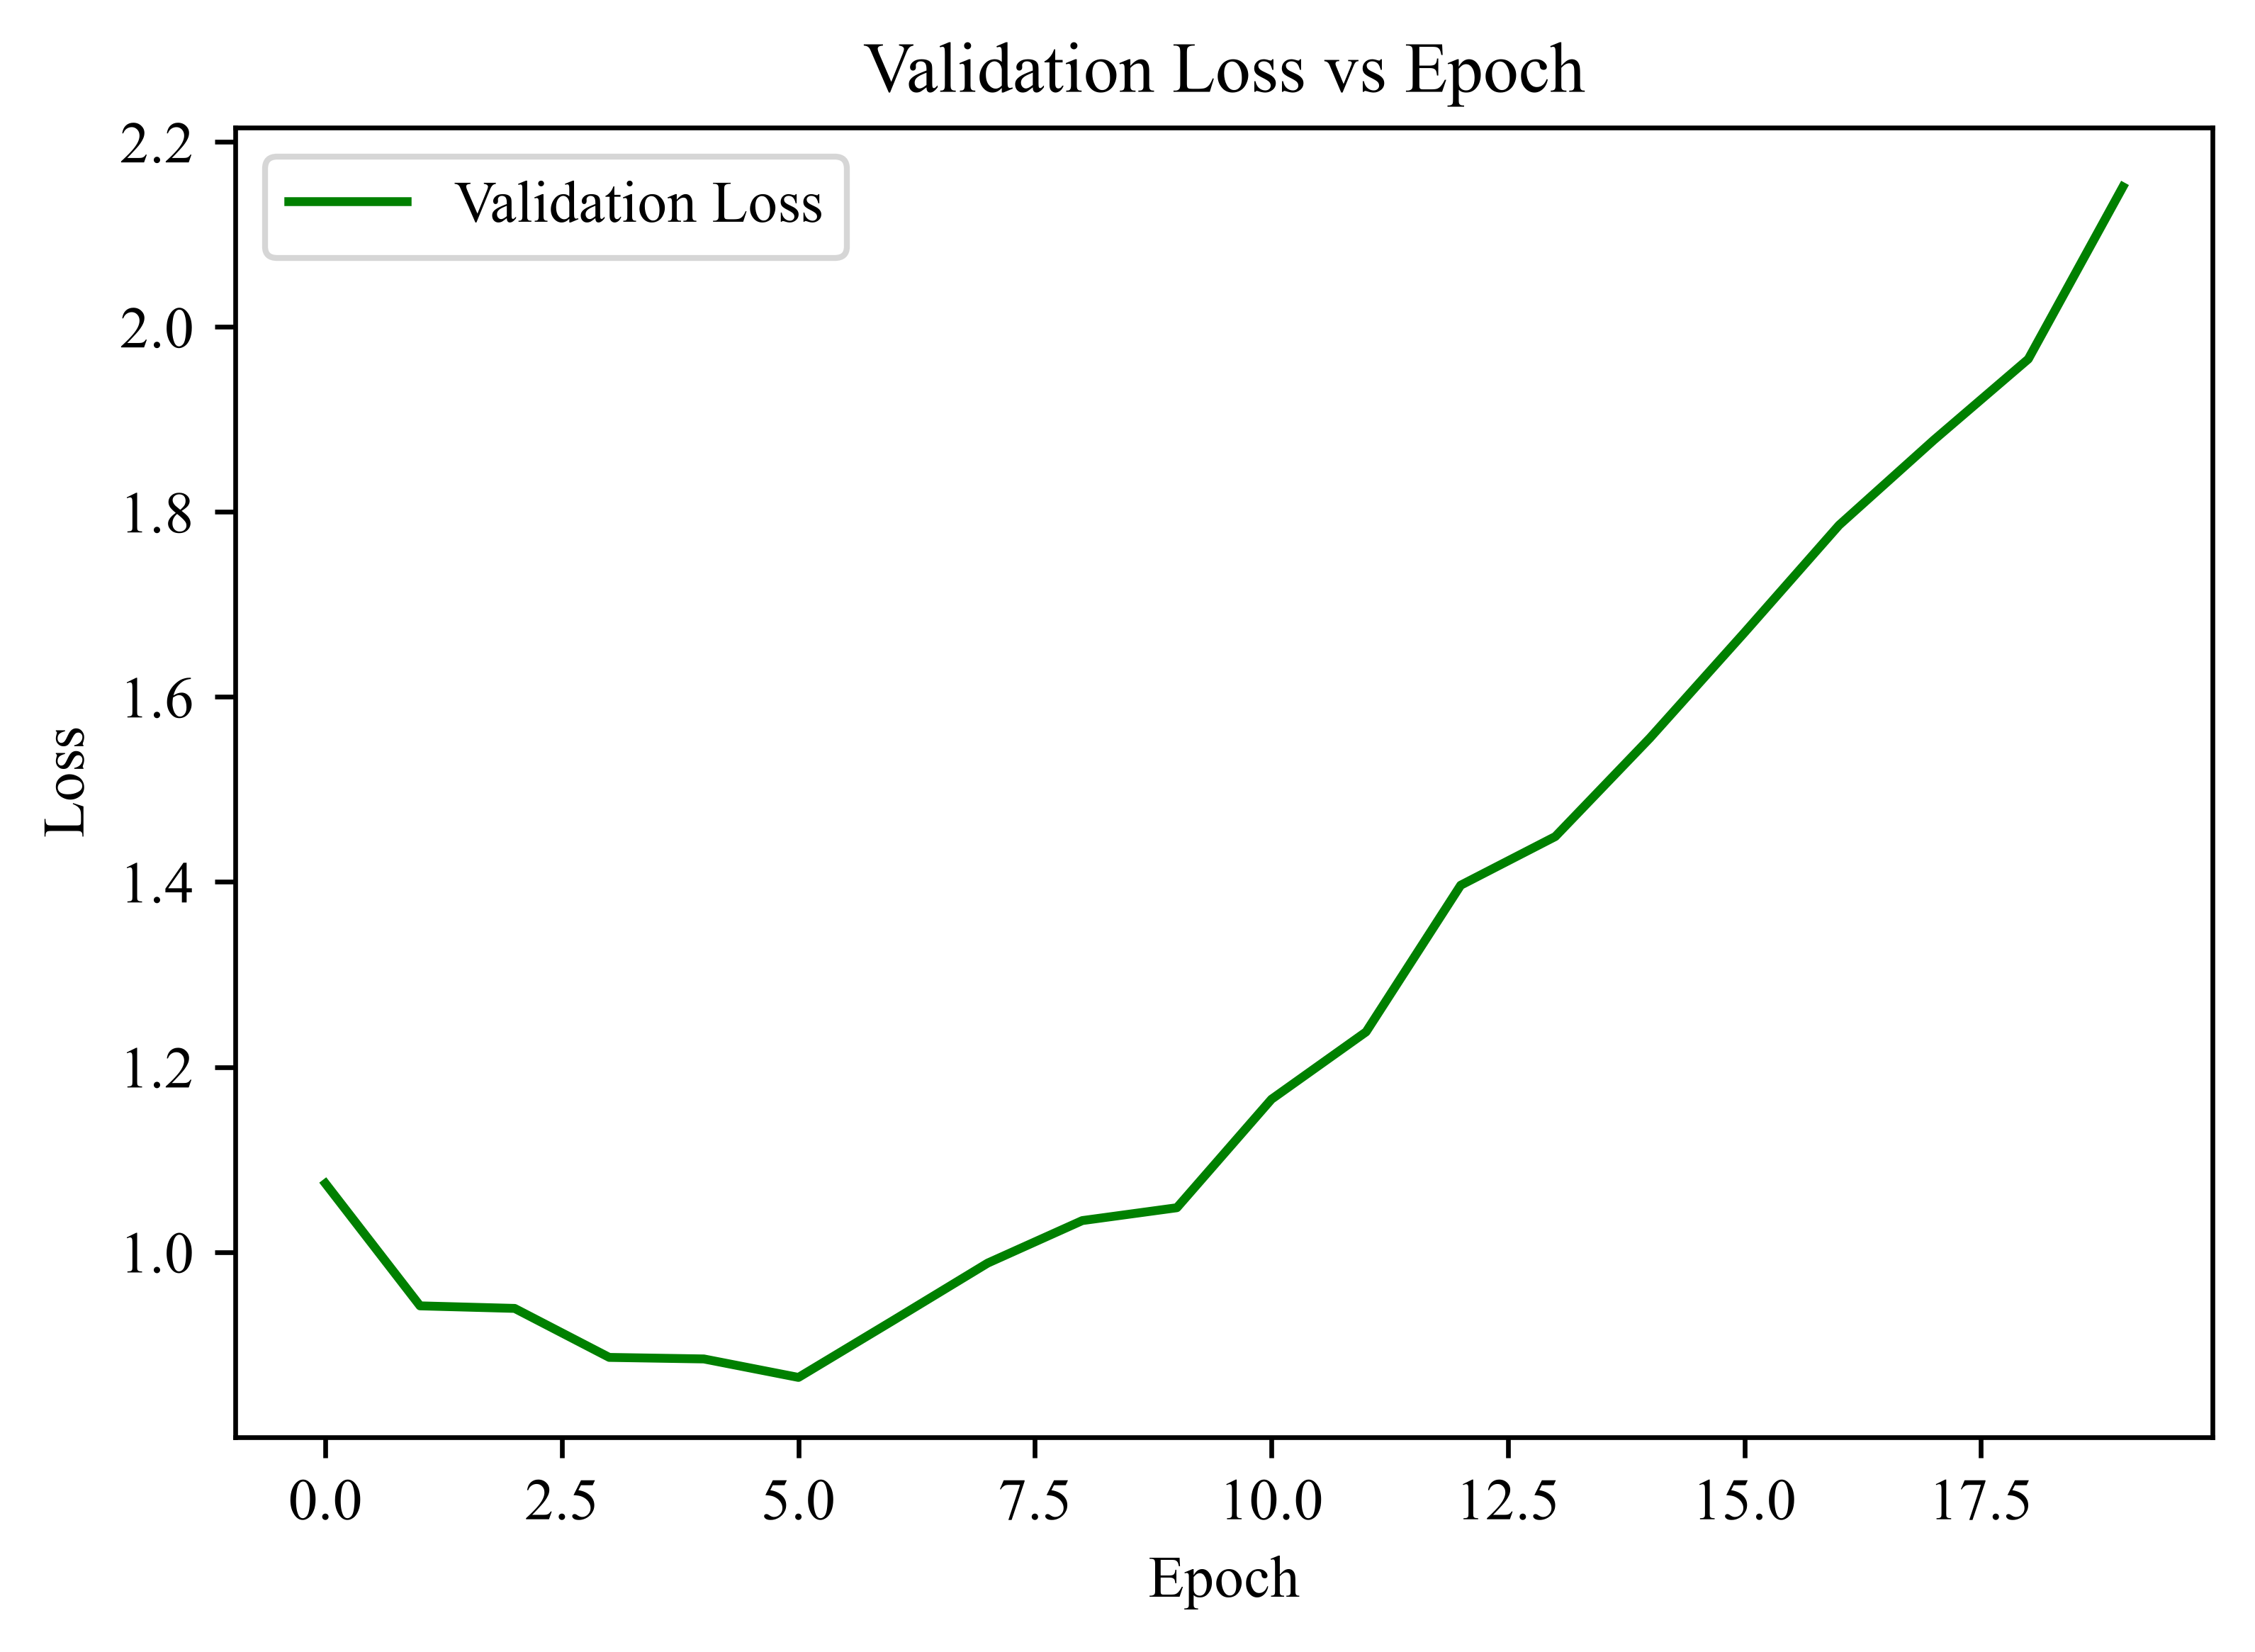

In [24]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss vs Epoch")
plt.legend()
save_plot("validation_loss")
plt.show()

# Inference: validation loss decreases initially but may flatten or slightly
# rise in the later epochs, which is a typical early sign of overfitting.


In [25]:
y_pred_probs = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy : 0.6841
Precision: 0.6890244763938492
Recall   : 0.6840999999999999
F1-score : 0.6838890062212795


In [26]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

    airplane       0.69      0.77      0.73      1000
  automobile       0.87      0.70      0.78      1000
        bird       0.55      0.58      0.57      1000
         cat       0.50      0.44      0.47      1000
        deer       0.69      0.56      0.62      1000
         dog       0.52      0.65      0.58      1000
        frog       0.76      0.75      0.75      1000
       horse       0.76      0.76      0.76      1000
        ship       0.79      0.82      0.80      1000
       truck       0.76      0.81      0.78      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



saved confusion_matrix.eps


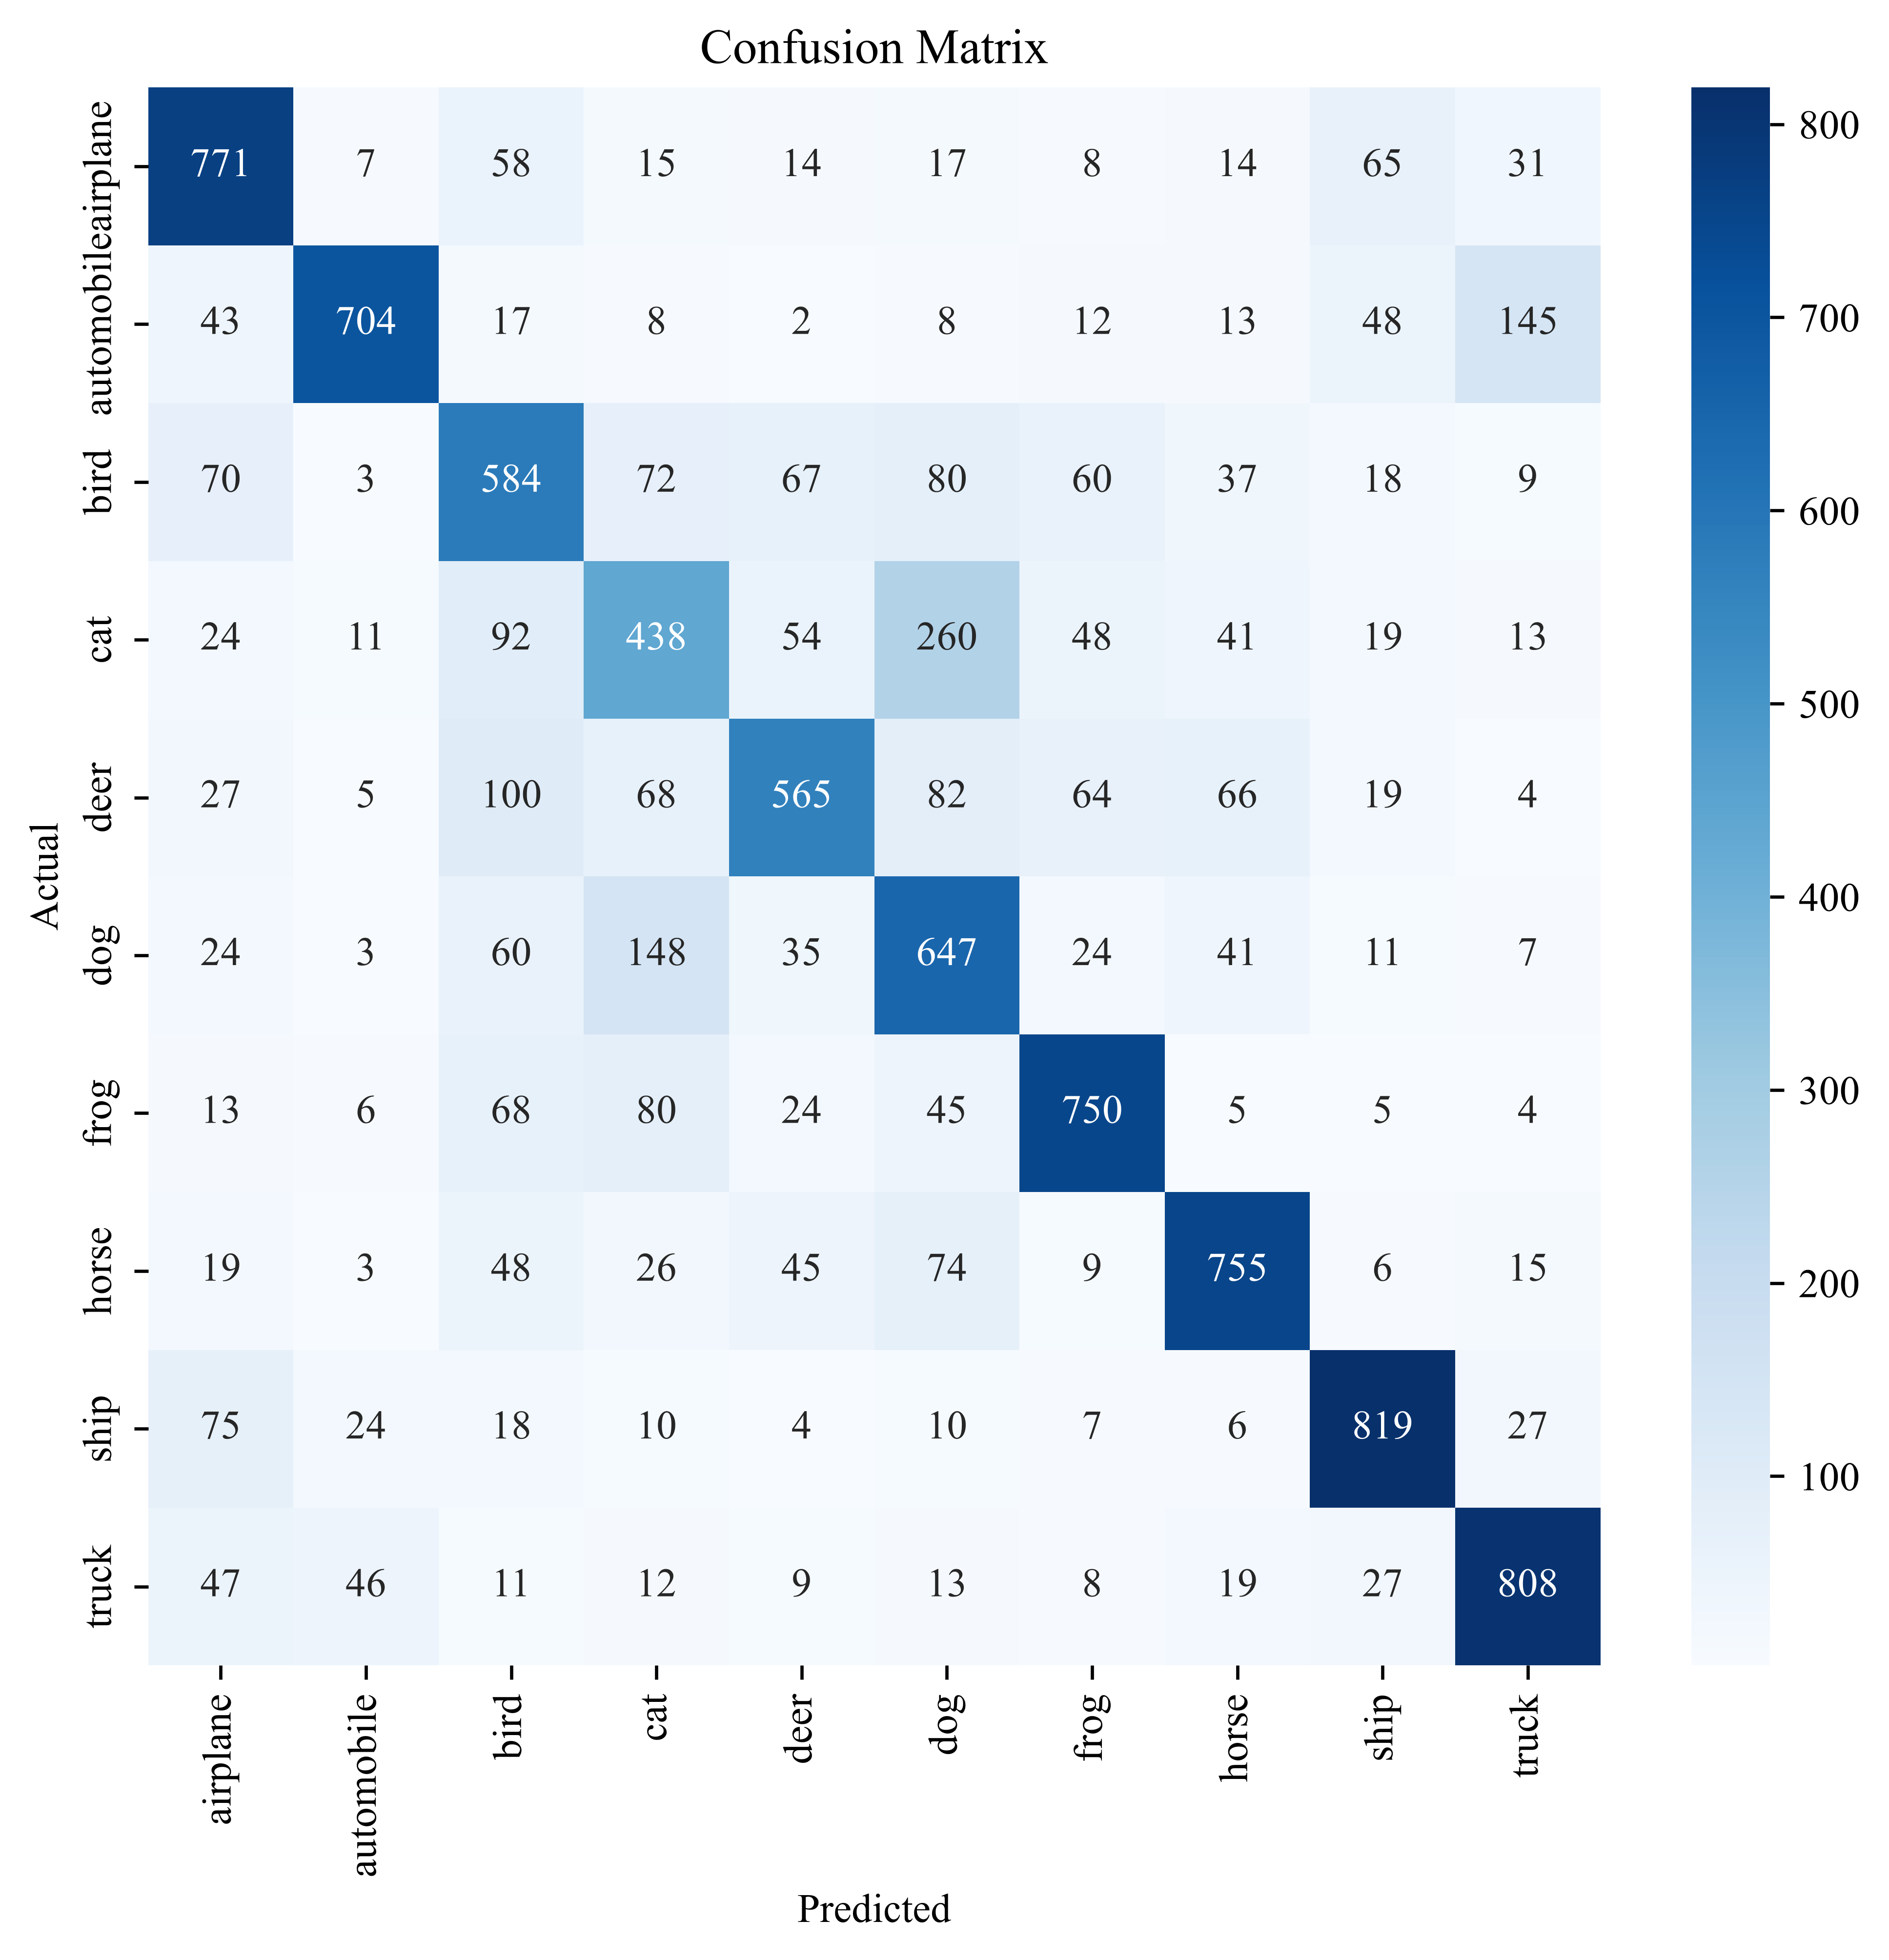

In [27]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
save_plot("confusion_matrix")
plt.show()

# Inference: the diagonal values are the highest in most rows meaning
# the model classifies most classes correctly, classes like cat and dog
# tend to get confused with each other more since they look visually similar.


Additional Exercise

In [30]:
# 1. Output size for 64x64 image, 5x5 kernel, stride 2, padding 2
size1 = compute_output_size(64, 5, 2, 2)
print("1. Output size (64x64, kernel=5, stride=2, padding=2):", size1)

1. Output size (64x64, kernel=5, stride=2, padding=2): 32


In [31]:
# 2. Trainable parameters for 64 filters of 3x3 kernel, RGB input (3 channels)
num_filters = 64
kernel_h, kernel_w, in_channels = 3, 3, 3
params = (kernel_h * kernel_w * in_channels + 1) * num_filters
print("2. Trainable parameters (64 filters, 3x3, RGB input):", params)

2. Trainable parameters (64 filters, 3x3, RGB input): 1792


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved relu_vs_sigmoid.eps


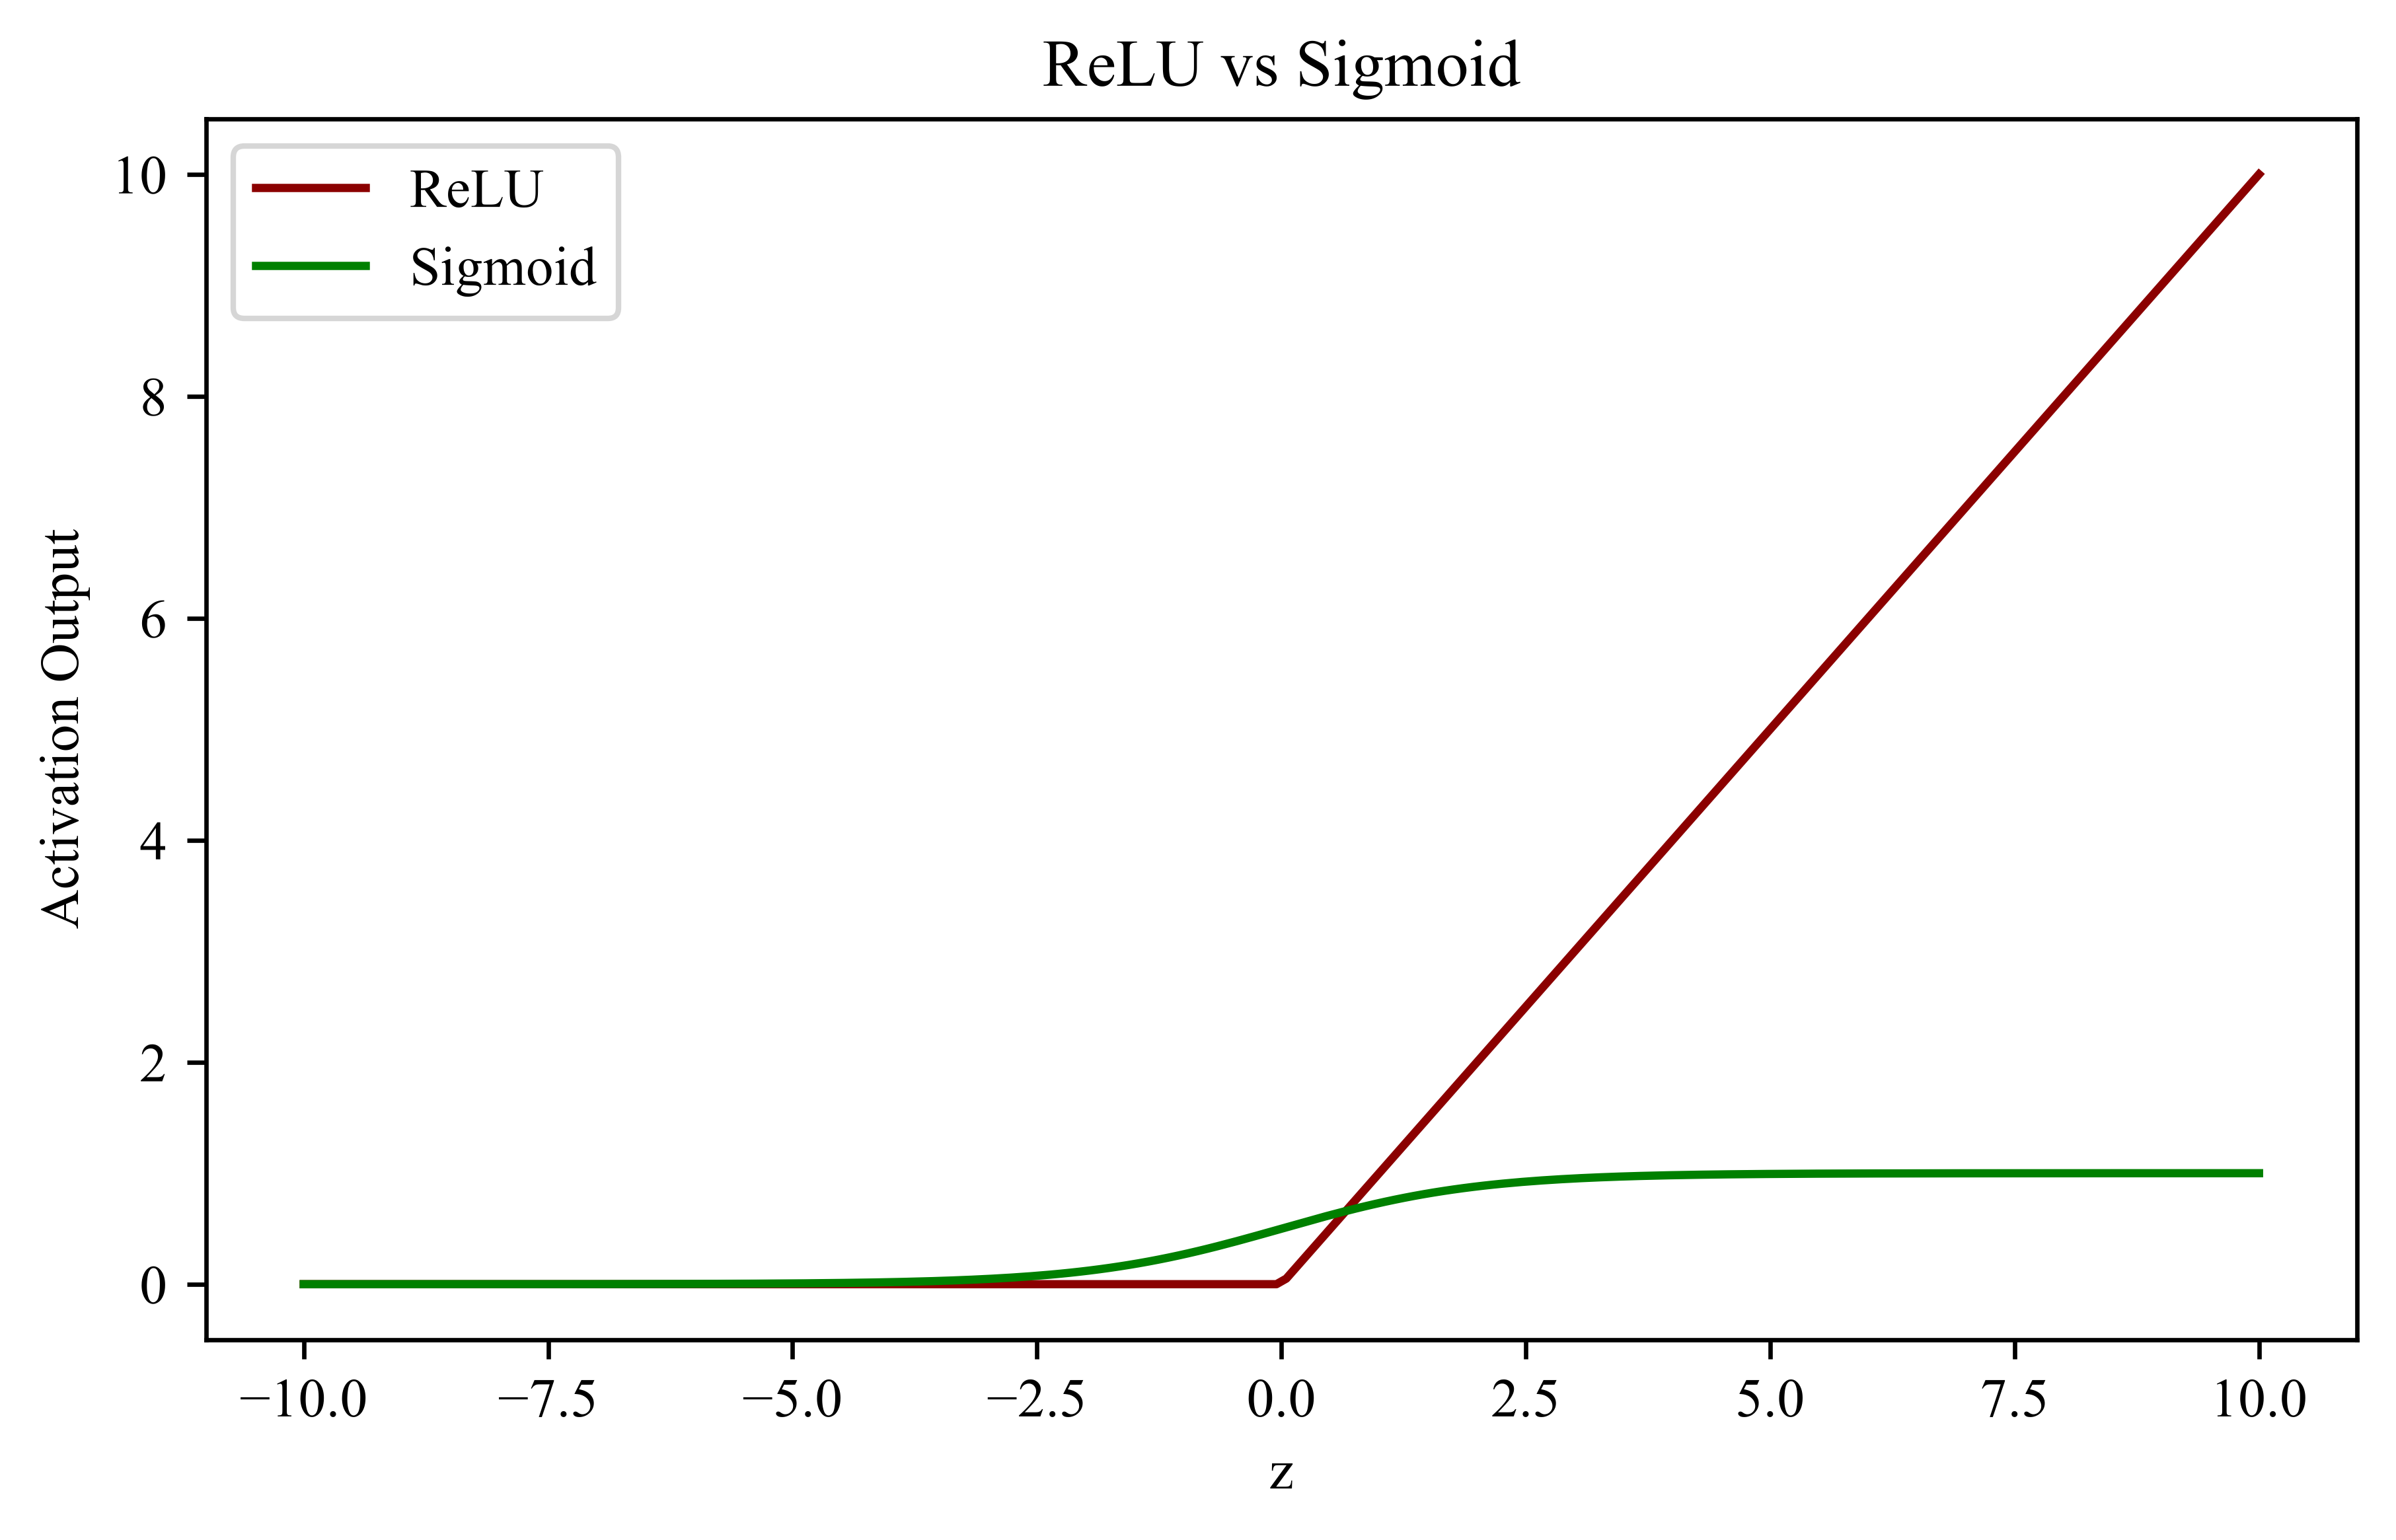

In [32]:
# 3. Compare ReLU and Sigmoid activation functions
z = np.linspace(-10, 10, 200)
relu = np.maximum(0, z)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(7, 4))
plt.plot(z, relu, label='ReLU', color='darkred')
plt.plot(z, sigmoid, label='Sigmoid', color='green')
plt.xlabel("z")
plt.ylabel("Activation Output")
plt.title("ReLU vs Sigmoid")
plt.legend()
save_plot("relu_vs_sigmoid")
plt.show()

# Inference: ReLU is linear and unbounded for positive inputs and zero for
# negative inputs, which avoids the vanishing gradient problem. Sigmoid
# squashes values between 0 and 1 and saturates for large positive or
# negative inputs, which slows down learning in deep networks.

In [33]:
# 4. Replace Max Pooling with Average Pooling in the CNN and compare results
model_avgpool = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.AveragePooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_avgpool.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

history_avgpool = model_avgpool.fit(X_train_norm, y_train_cat,
                                     epochs=20,
                                     batch_size=32,
                                     validation_data=(X_test_norm, y_test_cat))


c:\Users\Kishore\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.4728 - loss: 1.4695 - val_accuracy: 0.5432 - val_loss: 1.2651
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.5992 - loss: 1.1349 - val_accuracy: 0.6130 - val_loss: 1.0843
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6538 - loss: 0.9801 - val_accuracy: 0.6597 - val_loss: 0.9731
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6911 - loss: 0.8789 - val_accuracy: 0.6716 - val_loss: 0.9442
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7195 - loss: 0.7971 - val_accuracy: 0.6645 - val_loss: 0.9583
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7427 - loss: 0.7288 - val_accuracy: 0.7008 - val_loss: 0.8692
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7674 - loss: 0.6636 - val_accuracy: 0.6975 - val_loss: 0.9286
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7854 - loss: 0

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved maxpool_vs_avgpool.eps


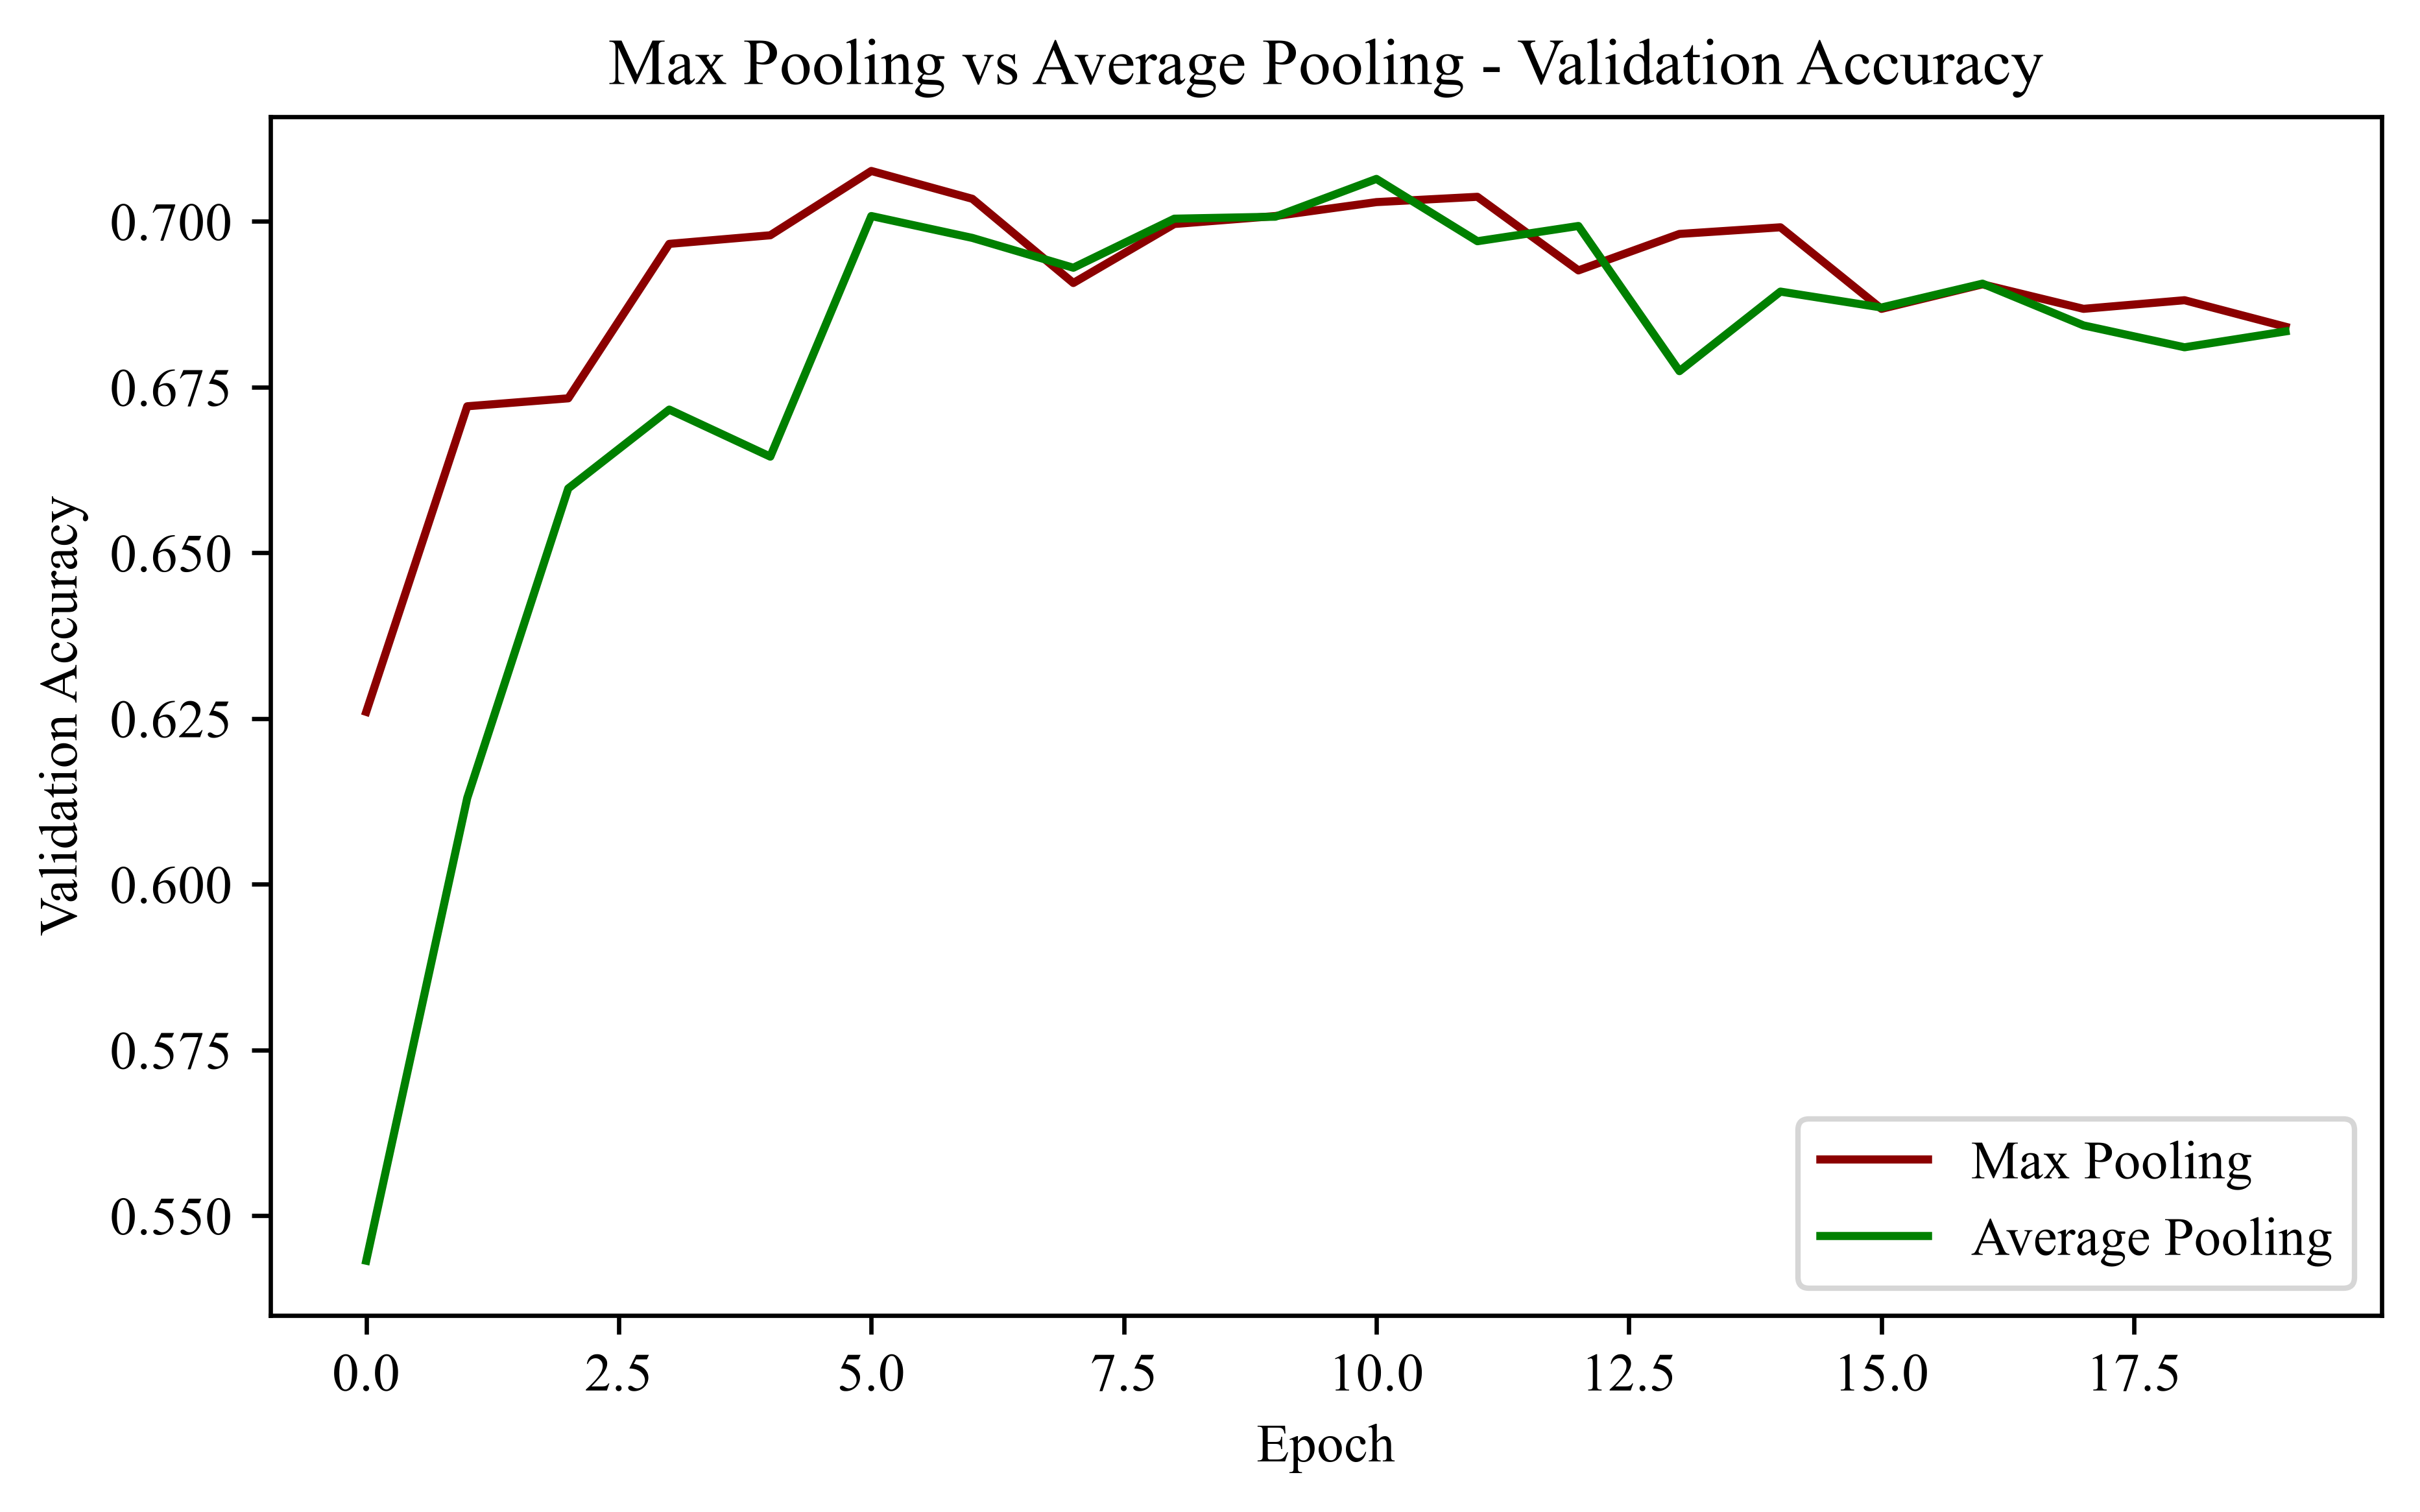

In [37]:
plt.figure(figsize=(7, 4))
plt.plot(history.history['val_accuracy'], label='Max Pooling', color='darkred')
plt.plot(history_avgpool.history['val_accuracy'], label='Average Pooling', color='green')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Max Pooling vs Average Pooling - Validation Accuracy")
plt.legend()
save_plot("maxpool_vs_avgpool")
plt.show()

# Inference: max pooling generally gives slightly better validation
# accuracy than average pooling for this dataset, since it preserves
# the strongest and most discriminative features rather than smoothing them out.

In [38]:
# 5. Increase number of filters from 16 to 64 and analyze effect on
#    accuracy and computation time
import time

filter_counts = [16, 64]
filter_results = {}

for nf in filter_counts:
    small_model = models.Sequential([
        layers.Conv2D(nf, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(nf * 2, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    small_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    start_time = time.time()
    hist = small_model.fit(X_train_norm, y_train_cat, epochs=5, batch_size=32,
                            validation_data=(X_test_norm, y_test_cat), verbose=0)
    end_time = time.time()

    filter_results[nf] = {
        'val_accuracy': hist.history['val_accuracy'][-1],
        'time_taken': end_time - start_time
    }
    print(f"Filters={nf} -> Final Val Accuracy: {filter_results[nf]['val_accuracy']:.4f}, "
          f"Time taken: {filter_results[nf]['time_taken']:.2f}s")

# Inference: increasing the number of filters from 16 to 64 improves the
# model's ability to capture more diverse features, generally improving
# accuracy, but it also increases the number of parameters and hence the
# training time noticeably.

Filters=16 -> Final Val Accuracy: 0.6723, Time taken: 53.19s
Filters=64 -> Final Val Accuracy: 0.7185, Time taken: 162.05s


# ## Discussion 
#
# 1. Why is convolution preferred over fully connected layers for images:
#    Convolution uses shared weights and local receptive fields, so it
#    needs far fewer parameters than a fully connected layer and can
#    detect the same pattern (like an edge) anywhere in the image.
#
# 2. How does stride affect the feature map size:
#    A larger stride makes the filter skip more pixels while sliding,
#    which reduces the size of the output feature map and also reduces
#    computation, but it can miss some finer details.
#
# 3. What is the role of padding:
#    Padding adds extra pixels (usually zeros) around the input so that
#    the filter can be applied to border pixels properly, 'same' padding
#    keeps the output size equal to the input size while 'valid' padding
#    shrinks the output.
#
# 4. Why is pooling used:
#    Pooling reduces the spatial dimensions of the feature maps, which
#    reduces the number of parameters and computation in later layers,
#    and also makes the model more robust to small translations in the image.
#
# 5. How do feature maps represent image characteristics:
#    Each feature map is the result of one filter scanning the image,
#    highlighting where a particular pattern (edge, texture, colour blob)
#    occurs, early layers capture low level features while deeper layers
#    capture more complex, abstract patterns.
#
# 6. Why do CNNs require fewer parameters than MLPs:
#    CNNs use small filters with shared weights across the entire image
#    instead of connecting every input pixel to every neuron like an MLP
#    does, this weight sharing drastically cuts down the number of
#    trainable parameters while still capturing spatial patterns effectively.